# HFENN Regression - 方案1: 时间感知特征实验

## 实验目标
在分布感知校准的基础上，添加时间相关特征，验证是否能提升R²

## 新增特征
1. **时间进度** `t_progress`: `window_idx / total_windows`，范围 [0, 1]
2. **Pulse滚动均值** `pulse_rolling_mean`: 过去10个窗口的Pulse均值
3. **Pulse滚动斜率** `pulse_rolling_slope`: 过去10个窗口的Pulse趋势

## 基线对比
- Baseline: 分布感知校准版本 (R² ≈ 0.695)
- 本实验: 添加时间特征后的效果

---
**版本**: v2.0 Temporal Features
**日期**: 2026-01-12
**基于**: HFENN_regression_personalized.ipynb (分布感知校准版)

In [1]:
# === Cell 1: 环境设置 ===
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from datetime import datetime
import random

from scipy.signal import find_peaks, hilbert, welch
from scipy.stats import skew, kurtosis
import pywt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

try:
    from keras import layers, models, Input, regularizers
    from keras.optimizers import Adam
    from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
    import keras.backend as K
    print("使用独立的 keras")
except ImportError:
    from tensorflow.keras import layers, models, Input, regularizers
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
    import tensorflow.keras.backend as K
    print("使用 tensorflow.keras")

np.random.seed(42)
random.seed(42)

# === 配置 ===
TEST_PARTICIPANT = 'gs1'  # 先跑单个参与者验证
CALIBRATION_RATIO = 0.30  # 校准集比例 (从0.10提升到0.30，增加校准样本数)
CALIB_VAL_SPLIT = 0.2     # 校准集中用于验证的比例 (24% train, 6% val)
WINDOW_SIZE = 2610
OVERLAP_RATIO = 0.5
CALIBRATION_OVERLAP_RATIO = 0.90  # 校准集切窗用更大overlap，增加样本数

print(f"HFENN Regression 个性化微调")
print(f"测试参与者: {TEST_PARTICIPANT}")
print(f"校准集比例: {CALIBRATION_RATIO*100:.0f}%")
print(f"校准集overlap: {CALIBRATION_OVERLAP_RATIO*100:.0f}% (步长更小，样本更多)")
print(f"开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

使用独立的 keras
HFENN Regression 个性化微调
测试参与者: gs1
校准集比例: 30%
校准集overlap: 90% (步长更小，样本更多)
开始时间: 2026-01-12 20:13:40


In [2]:
# === Cell 2: 加载所有参与者数据 ===
print("加载所有参与者数据...")

data_dir = 'data/processed'
all_files = glob.glob(os.path.join(data_dir, '*_continuous.csv'))

# 按参与者分别存储
participant_data = {}
for file in sorted(all_files):
    df_temp = pd.read_csv(file)
    pid = df_temp['Participant_ID'].iloc[0]
    participant_data[pid] = df_temp
    print(f"  {pid}: {len(df_temp)} 行")

all_participants = list(participant_data.keys())
print(f"\n共加载 {len(all_participants)} 个参与者: {all_participants}")

# 验证测试参与者存在
assert TEST_PARTICIPANT in all_participants, f"测试参与者 {TEST_PARTICIPANT} 不存在!"
print(f"\n✅ 测试参与者 {TEST_PARTICIPANT} 数据量: {len(participant_data[TEST_PARTICIPANT])} 行")

加载所有参与者数据...
  gs1: 4144548 行
  gs1: 294177 行
  gs2: 362371 行
  hww: 346701 行
  jz: 286751 行
  lx1: 333634 行
  lx2: 312330 行
  lx3: 318714 行
  pm: 310307 行
  ysp: 258053 行
  zch1: 364557 行
  zch2: 303580 行
  zm: 359880 行
  zxl: 293493 行

共加载 13 个参与者: ['gs1', 'gs2', 'hww', 'jz', 'lx1', 'lx2', 'lx3', 'pm', 'ysp', 'zch1', 'zch2', 'zm', 'zxl']

✅ 测试参与者 gs1 数据量: 294177 行


In [3]:
# === Cell 3: 数据预处理函数 ===
print("定义数据预处理函数...")

def per_participant_standardization(df, columns, fit_stats=None):
    """
    按参与者Z-Score标准化
    fit_stats: 如果提供，使用这些统计量（用于测试集）
    返回: (标准化后的df, 统计量dict)
    """
    df_std = df.copy()
    stats = {}
    
    for pid in df['Participant_ID'].unique():
        mask = df['Participant_ID'] == pid
        stats[pid] = {}
        
        for col in columns:
            if fit_stats and pid in fit_stats:
                mean_val = fit_stats[pid][col]['mean']
                std_val = fit_stats[pid][col]['std']
            else:
                mean_val = df.loc[mask, col].mean()
                std_val = df.loc[mask, col].std()
            
            stats[pid][col] = {'mean': mean_val, 'std': std_val}
            
            if std_val > 0:
                df_std.loc[mask, col] = (df.loc[mask, col] - mean_val) / std_val
            else:
                df_std.loc[mask, col] = 0
    
    return df_std, stats

def add_diff_signals(df):
    """添加差分信号"""
    df_with_diff = df.copy()
    df_with_diff['Pulse_Diff'] = 0.0
    df_with_diff['Fatigue_Diff'] = 0.0
    
    for pid in df['Participant_ID'].unique():
        mask = df['Participant_ID'] == pid
        df_with_diff.loc[mask, 'Pulse_Diff'] = df.loc[mask, 'Pulse'].diff().fillna(0).values
        df_with_diff.loc[mask, 'Fatigue_Diff'] = df.loc[mask, 'Fatigue'].diff().fillna(0).values
    
    return df_with_diff

print("预处理函数定义完成")

定义数据预处理函数...
预处理函数定义完成


In [4]:
# === Cell 4: 特征提取器 ===
print("构建四通道特征提取器...")

class QuadChannelFeatureExtractor:
    def __init__(self, sampling_rate=87):
        self.sampling_rate = sampling_rate
        
    def extract_time_domain_features(self, signal):
        features = []
        features.extend([
            np.mean(signal), np.std(signal), np.max(signal), np.min(signal),
            np.median(signal), skew(signal), kurtosis(signal), np.var(signal),
            np.ptp(signal), np.percentile(signal, 25), np.percentile(signal, 75),
            len(find_peaks(signal)[0]), len(find_peaks(-signal)[0]),
            np.sum(signal**2), np.mean(signal**2), np.sqrt(np.mean(signal**2)),
        ])
        return features
    
    def extract_frequency_domain_features(self, signal):
        features = []
        freqs, psd = welch(signal, fs=self.sampling_rate, nperseg=min(256, len(signal)//4))
        features.extend([np.mean(psd), np.std(psd), np.max(psd),
                        freqs[np.argmax(psd)] if len(psd) > 0 else 0, np.sum(psd)])
        freq_bands = [(0, 1), (1, 5), (5, 15), (15, 25)]
        total_power = np.sum(psd)
        for low, high in freq_bands:
            band_mask = (freqs >= low) & (freqs <= high)
            band_power = np.sum(psd[band_mask])
            features.append(band_power / total_power if total_power > 0 else 0)
        return features
    
    def extract_wavelet_features(self, signal):
        features = []
        coeffs = pywt.wavedec(signal, 'db4', level=4)
        for coeff in coeffs:
            if len(coeff) > 0:
                features.extend([np.mean(coeff), np.std(coeff), np.sum(coeff**2), np.max(np.abs(coeff))])
        return features
    
    def extract_nonlinear_features(self, signal):
        features = []
        analytic_signal = hilbert(signal)
        amplitude_envelope = np.abs(analytic_signal)
        instantaneous_phase = np.angle(analytic_signal)
        features.extend([np.mean(amplitude_envelope), np.std(amplitude_envelope),
                        np.mean(np.diff(instantaneous_phase))])
        zero_crossings = np.sum(np.diff(np.sign(signal - np.mean(signal))) != 0) / len(signal)
        features.append(zero_crossings)
        return features
    
    def extract_diff_features(self, diff_signal):
        features = []
        features.extend([
            np.mean(diff_signal), np.std(diff_signal), np.max(diff_signal), np.min(diff_signal),
            np.sum(diff_signal > 0) / len(diff_signal), np.sum(diff_signal < 0) / len(diff_signal),
            np.sum(np.abs(diff_signal)), np.mean(np.abs(diff_signal)),
            skew(diff_signal), kurtosis(diff_signal),
        ])
        return features
    
    def extract_single_channel_features(self, signal):
        all_features = []
        all_features.extend(self.extract_time_domain_features(signal))
        all_features.extend(self.extract_frequency_domain_features(signal))
        all_features.extend(self.extract_wavelet_features(signal))
        all_features.extend(self.extract_nonlinear_features(signal))
        return np.array(all_features)
    
    def extract_quad_channel_features(self, pulse, fatigue, pulse_diff, fatigue_diff):
        pulse_features = self.extract_single_channel_features(pulse)
        fatigue_features = self.extract_single_channel_features(fatigue)
        pulse_diff_features = self.extract_diff_features(pulse_diff)
        fatigue_diff_features = self.extract_diff_features(fatigue_diff)
        return np.concatenate([pulse_features, fatigue_features, pulse_diff_features, fatigue_diff_features])

feature_extractor = QuadChannelFeatureExtractor()
print("特征提取器构建完成")

构建四通道特征提取器...
特征提取器构建完成


In [5]:
# === Cell 5: 数据分段函数 (修复：按Participant_ID分组滑窗) ===
print("定义数据分段函数...")

def extract_segments_from_df(df, window_size=2610, overlap_ratio=0.5):
    """
    从DataFrame提取分段数据 - 按参与者分组滑窗，避免跨人边界
    返回: pulse_ts, fatigue_ts, features, targets, time_indices, participant_ids, window_indices
    time_indices用于验证时间顺序
    window_indices用于计算时间进度特征
    """
    step = int(window_size * (1 - overlap_ratio))
    
    pulse_segments, fatigue_segments = [], []
    enhanced_features, target_values, time_indices, segment_pids, window_indices = [], [], [], [], []
    
    # 按参与者分组处理，避免跨人边界
    for pid in df['Participant_ID'].unique():
        df_p = df[df['Participant_ID'] == pid].reset_index(drop=True)
        
        pulse_data = df_p['Pulse'].values
        fatigue_data = df_p['Fatigue'].values
        pulse_diff_data = df_p['Pulse_Diff'].values
        fatigue_diff_data = df_p['Fatigue_Diff'].values
        target_data = df_p['Fatigue_Score_Smoothed'].values
        
        # 计算该参与者的总窗口数
        n_windows_pid = (len(pulse_data) - window_size) // step + 1
        
        for win_idx, start in enumerate(range(0, len(pulse_data) - window_size + 1, step)):
            end = start + window_size
            
            pulse_seg = pulse_data[start:end]
            fatigue_seg = fatigue_data[start:end]
            pulse_diff_seg = pulse_diff_data[start:end]
            fatigue_diff_seg = fatigue_diff_data[start:end]
            target_seg = target_data[start:end]
            
            pulse_segments.append(pulse_seg)
            fatigue_segments.append(fatigue_seg)
            
            features = feature_extractor.extract_quad_channel_features(
                pulse_seg, fatigue_seg, pulse_diff_seg, fatigue_diff_seg)
            enhanced_features.append(features)
            
            target_values.append(target_seg[-1])
            time_indices.append(end)
            segment_pids.append(pid)
            window_indices.append(win_idx)  # 窗口在该参与者内的索引
    
    return (np.array(pulse_segments), np.array(fatigue_segments), 
            np.array(enhanced_features), np.array(target_values), 
            np.array(time_indices), np.array(segment_pids), np.array(window_indices))

def extract_segments_single_participant(df, window_size=2610, overlap_ratio=0.5):
    """
    从单个参与者的DataFrame提取分段数据
    用于测试者数据，保证时间顺序
    返回: pulse_ts, fatigue_ts, features, targets, time_indices, window_indices
    """
    step = int(window_size * (1 - overlap_ratio))
    
    pulse_segments, fatigue_segments = [], []
    enhanced_features, target_values, time_indices, window_indices = [], [], [], []
    
    pulse_data = df['Pulse'].values
    fatigue_data = df['Fatigue'].values
    pulse_diff_data = df['Pulse_Diff'].values
    fatigue_diff_data = df['Fatigue_Diff'].values
    target_data = df['Fatigue_Score_Smoothed'].values
    
    for win_idx, start in enumerate(range(0, len(pulse_data) - window_size + 1, step)):
        end = start + window_size
        
        pulse_seg = pulse_data[start:end]
        fatigue_seg = fatigue_data[start:end]
        pulse_diff_seg = pulse_diff_data[start:end]
        fatigue_diff_seg = fatigue_diff_data[start:end]
        target_seg = target_data[start:end]
        
        pulse_segments.append(pulse_seg)
        fatigue_segments.append(fatigue_seg)
        
        features = feature_extractor.extract_quad_channel_features(
            pulse_seg, fatigue_seg, pulse_diff_seg, fatigue_diff_seg)
        enhanced_features.append(features)
        
        target_values.append(target_seg[-1])
        time_indices.append(end)
        window_indices.append(win_idx)
    
    return (np.array(pulse_segments), np.array(fatigue_segments), 
            np.array(enhanced_features), np.array(target_values), 
            np.array(time_indices), np.array(window_indices))

print("数据分段函数定义完成")
print("  ✅ extract_segments_from_df: 按Participant_ID分组滑窗，返回窗口索引")
print("  ✅ extract_segments_single_participant: 单参与者分段，返回窗口索引")

定义数据分段函数...
数据分段函数定义完成
  ✅ extract_segments_from_df: 按Participant_ID分组滑窗，返回窗口索引
  ✅ extract_segments_single_participant: 单参与者分段，返回窗口索引


In [6]:
# === Cell 6: 小波变换函数 ===
print("定义小波变换函数...")

def apply_wavelet_transform(data, wavelet='db4', level=4):
    """对时间序列数据应用小波变换"""
    n_samples, seq_len = data.shape
    
    # 计算各层系数长度
    coeffs_sample = pywt.wavedec(data[0], wavelet, level=level)
    coeff_lengths = [len(c) for c in coeffs_sample]
    total_len = sum(coeff_lengths)
    
    # 批量处理
    wavelet_features = np.zeros((n_samples, total_len))
    for i in range(n_samples):
        coeffs = pywt.wavedec(data[i], wavelet, level=level)
        wavelet_features[i] = np.concatenate(coeffs)
    
    return wavelet_features

def apply_feature_smoothing(features, window_size=5):
    """
    特征平滑 - 自适应处理小样本情况
    如果样本数小于window_size，则使用较小的窗口或直接返回原数据
    """
    n_samples = features.shape[0]
    
    # 如果样本数太少，跳过平滑
    if n_samples < 3:
        print(f"  ⚠️ 样本数过少({n_samples})，跳过特征平滑")
        return features.copy()
    
    # 自适应窗口大小
    actual_window = min(window_size, n_samples)
    if actual_window % 2 == 0:  # 确保窗口为奇数
        actual_window = max(1, actual_window - 1)
    
    if actual_window != window_size:
        print(f"  ⚠️ 样本数({n_samples})较少，窗口从{window_size}调整为{actual_window}")
    
    smoothed = np.zeros_like(features)
    kernel = np.ones(actual_window) / actual_window
    
    for i in range(features.shape[1]):
        # 使用 'same' 模式保持输出长度
        conv_result = np.convolve(features[:, i], kernel, mode='same')
        smoothed[:, i] = conv_result
    
    return smoothed

print("小波变换函数定义完成")
print("  ✅ apply_feature_smoothing: 自适应处理小样本情况")

定义小波变换函数...
小波变换函数定义完成
  ✅ apply_feature_smoothing: 自适应处理小样本情况


In [7]:
# === Cell 7: HFENN模型构建 ===
print("构建HFENN回归模型...")

def residual_attention_block(x, filters, kernel_size=3, name_prefix=''):
    """残差注意力模块"""
    # 主路径
    conv1 = layers.Conv1D(filters, kernel_size, padding='same', activation='relu',
                          name=f'{name_prefix}_conv1')(x)
    conv2 = layers.Conv1D(filters, kernel_size, padding='same',
                          name=f'{name_prefix}_conv2')(conv1)
    
    # 注意力机制
    attention = layers.GlobalAveragePooling1D(name=f'{name_prefix}_gap')(conv2)
    attention = layers.Dense(filters // 4, activation='relu', name=f'{name_prefix}_att_dense1')(attention)
    attention = layers.Dense(filters, activation='sigmoid', name=f'{name_prefix}_att_dense2')(attention)
    attention = layers.Reshape((1, filters), name=f'{name_prefix}_reshape')(attention)
    attended = layers.Multiply(name=f'{name_prefix}_multiply')([conv2, attention])
    
    # 残差连接
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding='same', name=f'{name_prefix}_shortcut')(x)
    
    output = layers.Add(name=f'{name_prefix}_add')([x, attended])
    output = layers.Activation('relu', name=f'{name_prefix}_relu')(output)
    return output

def build_hfenn_model(pulse_wavelet_dim, fatigue_wavelet_dim, enhanced_feature_dim, n_selected_features):
    """构建完整的HFENN回归模型"""
    
    # === 输入层 ===
    pulse_wavelet_input = Input(shape=(pulse_wavelet_dim, 1), name='pulse_wavelet_input')
    fatigue_wavelet_input = Input(shape=(fatigue_wavelet_dim, 1), name='fatigue_wavelet_input')
    pulse_diff_wavelet_input = Input(shape=(pulse_wavelet_dim, 1), name='pulse_diff_wavelet_input')
    fatigue_diff_wavelet_input = Input(shape=(fatigue_wavelet_dim, 1), name='fatigue_diff_wavelet_input')
    enhanced_feature_input = Input(shape=(n_selected_features,), name='enhanced_feature_input')
    
    # === 小波分支 (特征提取层 - 微调时冻结) ===
    # Pulse分支
    pulse_x = residual_attention_block(pulse_wavelet_input, 64, name_prefix='pulse_block1')
    pulse_x = layers.MaxPooling1D(2, name='pulse_pool1')(pulse_x)
    pulse_x = residual_attention_block(pulse_x, 128, name_prefix='pulse_block2')
    pulse_x = layers.GlobalAveragePooling1D(name='pulse_gap')(pulse_x)
    
    # Fatigue分支
    fatigue_x = residual_attention_block(fatigue_wavelet_input, 64, name_prefix='fatigue_block1')
    fatigue_x = layers.MaxPooling1D(2, name='fatigue_pool1')(fatigue_x)
    fatigue_x = residual_attention_block(fatigue_x, 128, name_prefix='fatigue_block2')
    fatigue_x = layers.GlobalAveragePooling1D(name='fatigue_gap')(fatigue_x)
    
    # Pulse Diff分支
    pulse_diff_x = residual_attention_block(pulse_diff_wavelet_input, 64, name_prefix='pulse_diff_block1')
    pulse_diff_x = layers.MaxPooling1D(2, name='pulse_diff_pool1')(pulse_diff_x)
    pulse_diff_x = residual_attention_block(pulse_diff_x, 128, name_prefix='pulse_diff_block2')
    pulse_diff_x = layers.GlobalAveragePooling1D(name='pulse_diff_gap')(pulse_diff_x)
    
    # Fatigue Diff分支
    fatigue_diff_x = residual_attention_block(fatigue_diff_wavelet_input, 64, name_prefix='fatigue_diff_block1')
    fatigue_diff_x = layers.MaxPooling1D(2, name='fatigue_diff_pool1')(fatigue_diff_x)
    fatigue_diff_x = residual_attention_block(fatigue_diff_x, 128, name_prefix='fatigue_diff_block2')
    fatigue_diff_x = layers.GlobalAveragePooling1D(name='fatigue_diff_gap')(fatigue_diff_x)
    
    # === 增强特征分支 ===
    enhanced_x = layers.Dense(64, activation='relu', name='enhanced_dense1')(enhanced_feature_input)
    enhanced_x = layers.Dropout(0.3, name='enhanced_dropout1')(enhanced_x)
    enhanced_x = layers.Dense(32, activation='relu', name='enhanced_dense2')(enhanced_x)
    
    # === 融合层 (可选解冻) ===
    merged = layers.Concatenate(name='fusion_concat')([pulse_x, fatigue_x, pulse_diff_x, fatigue_diff_x, enhanced_x])
    merged = layers.Dense(256, activation='relu', name='fusion_dense1')(merged)
    merged = layers.Dropout(0.4, name='fusion_dropout1')(merged)
    merged = layers.Dense(128, activation='relu', name='fusion_dense2')(merged)
    merged = layers.Dropout(0.3, name='fusion_dropout2')(merged)
    
    # === 回归头 (微调时训练) ===
    output = layers.Dense(64, activation='relu', name='regression_head_dense1')(merged)
    output = layers.Dense(32, activation='relu', name='regression_head_dense2')(output)
    output = layers.Dense(1, activation='sigmoid', name='regression_output')(output)
    
    model = models.Model(
        inputs=[pulse_wavelet_input, fatigue_wavelet_input, 
                pulse_diff_wavelet_input, fatigue_diff_wavelet_input, 
                enhanced_feature_input],
        outputs=output,
        name='HFENN_Regression'
    )
    
    return model

print("HFENN模型构建函数定义完成")

构建HFENN回归模型...
HFENN模型构建函数定义完成


In [8]:
# === Cell 8: 微调策略函数 (修复版：极简微调防止过拟合) ===
print("定义微调策略...")

def freeze_feature_extraction_layers(model):
    """
    Stage A: 冻结所有层，只训练最后输出层 (极简微调)
    
    修复过拟合问题：
    - 原方案: 训练3层 (10,369参数) vs 17样本 → 严重过拟合
    - 新方案: 只训练1层 (33参数) vs 17样本 → 参数/样本比约2:1
    
    可训练层 (共1层):
    - regression_output (1 unit, 33参数)
    """
    trainable_layer_names = ['regression_output']  # 只训练最后一层
    
    for layer in model.layers:
        if layer.name in trainable_layer_names:
            layer.trainable = True
        else:
            layer.trainable = False
    
    # 统计并验证
    trainable_layers = [l.name for l in model.layers if l.trainable]
    frozen_layers = [l.name for l in model.layers if not l.trainable]
    trainable_params = sum([np.prod(w.shape) for l in model.layers if l.trainable for w in l.weights])
    
    print(f"  Stage A 冻结策略 (极简版):")
    print(f"    冻结层数: {len(frozen_layers)}")
    print(f"    可训练层数: {len(trainable_layers)}")
    print(f"    可训练层: {trainable_layers}")
    print(f"    可训练参数量: {trainable_params:,}")
    print(f"    参数/样本比: 约 {trainable_params/17:.1f}:1 (目标<10:1)")
    
    return model

def unfreeze_fusion_layers(model):
    """
    Stage B: 解冻回归头 (不含融合层)，用极小LR微调
    
    修复过拟合问题：
    - 原方案: 5层 (182,785参数) → 严重过拟合
    - 新方案: 3层 (10,369参数) → 仍有风险但可尝试
    
    解冻层 (共3层):
    - regression_head_dense1 (64 units)
    - regression_head_dense2 (32 units)
    - regression_output (1 unit)
    """
    unfreeze_layer_names = [
        'regression_head_dense1', 'regression_head_dense2', 'regression_output'
    ]
    
    for layer in model.layers:
        if layer.name in unfreeze_layer_names:
            layer.trainable = True
        else:
            layer.trainable = False
    
    # 统计并验证
    trainable_layers = [l.name for l in model.layers if l.trainable]
    frozen_layers = [l.name for l in model.layers if not l.trainable]
    trainable_params = sum([np.prod(w.shape) for l in model.layers if l.trainable for w in l.weights])
    
    print(f"  Stage B 解冻策略 (保守版):")
    print(f"    冻结层数: {len(frozen_layers)}")
    print(f"    可训练层数: {len(trainable_layers)}")
    print(f"    可训练层: {trainable_layers}")
    print(f"    可训练参数量: {trainable_params:,}")
    
    return model

def unfreeze_all(model):
    """解冻所有层（用于训练Base Model）"""
    for layer in model.layers:
        layer.trainable = True
    return model

def print_layer_trainability(model):
    """打印所有层的可训练状态（用于调试）"""
    print("\n层可训练状态:")
    for layer in model.layers:
        if hasattr(layer, 'trainable'):
            status = "✓ 可训练" if layer.trainable else "✗ 冻结"
            print(f"  {layer.name}: {status}")

print("微调策略定义完成")
print("  Stage A: 只训练输出层 (1层, ~33参数) - 极简微调")
print("  Stage B: 训练回归头 (3层, ~10K参数) - 保守微调")

定义微调策略...
微调策略定义完成
  Stage A: 只训练输出层 (1层, ~33参数) - 极简微调
  Stage B: 训练回归头 (3层, ~10K参数) - 保守微调


In [9]:
# === Cell 9: 准备数据 (分布感知校准版) ===
print("="*60)
print("准备训练数据 - 严格LOSO验证 (分布感知校准版)")
print("="*60)

# Step 1: 分离训练参与者和测试参与者
train_participants = [p for p in all_participants if p != TEST_PARTICIPANT]
print(f"\n训练参与者 ({len(train_participants)}人): {train_participants}")
print(f"测试参与者: {TEST_PARTICIPANT}")

# Step 2: 合并训练参与者数据
train_dfs = [participant_data[p] for p in train_participants]
df_train_all = pd.concat(train_dfs, ignore_index=True)
print(f"\n训练集原始数据: {len(df_train_all)} 行")

# Step 3: 获取测试参与者原始数据
df_test_participant = participant_data[TEST_PARTICIPANT].copy()
n_test_total = len(df_test_participant)
print(f"测试参与者原始数据: {n_test_total} 行")

# ============================================================
# 标准化策略C: 用时间前缀行的统计量标准化整段数据
# 分层采样只决定"哪些窗口用于校准监督"，不改变标准化的因果性
# ============================================================
STANDARDIZATION_RATIO = 0.30  # 用于计算标准化统计量的时间前缀比例
n_std_rows = int(n_test_total * STANDARDIZATION_RATIO)
print(f"\n标准化策略: 用时间前缀 {STANDARDIZATION_RATIO*100:.0f}% ({n_std_rows} 行) 计算统计量")

# 计算时间前缀的统计量
df_std_prefix = df_test_participant.iloc[:n_std_rows]
std_stats = {TEST_PARTICIPANT: {}}
for col in ['Pulse', 'Fatigue']:
    std_stats[TEST_PARTICIPANT][col] = {
        'mean': df_std_prefix[col].mean(),
        'std': df_std_prefix[col].std()
    }
print(f"  Pulse: mean={std_stats[TEST_PARTICIPANT]['Pulse']['mean']:.4f}, "
      f"std={std_stats[TEST_PARTICIPANT]['Pulse']['std']:.4f}")
print(f"  Fatigue: mean={std_stats[TEST_PARTICIPANT]['Fatigue']['mean']:.4f}, "
      f"std={std_stats[TEST_PARTICIPANT]['Fatigue']['std']:.4f}")

# Step 4: 对训练数据进行标准化 (只在训练集fit)
print("\n对训练数据进行标准化...")
df_train_std, train_stats = per_participant_standardization(
    df_train_all, ['Pulse', 'Fatigue'])
df_train_std = add_diff_signals(df_train_std)

# Step 5: 对测试参与者整段数据进行标准化 (用时间前缀统计量)
print("对测试参与者整段数据进行标准化 (用时间前缀统计量)...")
df_test_participant_std, _ = per_participant_standardization(
    df_test_participant, ['Pulse', 'Fatigue'], fit_stats=std_stats)
df_test_participant_std = add_diff_signals(df_test_participant_std)

print("\n✅ 数据标准化完成")
print(f"  训练集参与者: {df_train_std['Participant_ID'].unique().tolist()}")
print(f"  测试参与者: {TEST_PARTICIPANT}")
print(f"  ✅ 测试者标准化用时间前缀({n_std_rows}行)的统计量，无未来信息泄露")

准备训练数据 - 严格LOSO验证 (分布感知校准版)

训练参与者 (12人): ['gs2', 'hww', 'jz', 'lx1', 'lx2', 'lx3', 'pm', 'ysp', 'zch1', 'zch2', 'zm', 'zxl']
测试参与者: gs1

训练集原始数据: 3850371 行
测试参与者原始数据: 294177 行

标准化策略: 用时间前缀 30% (88253 行) 计算统计量
  Pulse: mean=32.5107, std=7.8239
  Fatigue: mean=71.9217, std=1.0841

对训练数据进行标准化...
对测试参与者整段数据进行标准化 (用时间前缀统计量)...

✅ 数据标准化完成
  训练集参与者: ['gs2', 'hww', 'jz', 'lx1', 'lx2', 'lx3', 'pm', 'ysp', 'zch1', 'zch2', 'zm', 'zxl']
  测试参与者: gs1
  ✅ 测试者标准化用时间前缀(88253行)的统计量，无未来信息泄露


In [10]:
# === Cell 10: 分布感知校准 - 窗口级分层采样 ===
print("="*60)
print("分布感知校准 - 窗口级分层采样")
print("="*60)

# ============================================================
# Step 1: 对测试者整段数据切窗口 (覆盖全时间)
# ============================================================
print("\n【Step 1】对测试者整段数据切窗口...")
(X_pulse_all, X_fatigue_all, X_features_all, 
 y_all, time_idx_all, window_idx_all) = extract_segments_single_participant(
    df_test_participant_std, WINDOW_SIZE, OVERLAP_RATIO)

n_total_windows = len(y_all)
print(f"  总窗口数: {n_total_windows}")
print(f"  Target范围: [{y_all.min():.4f}, {y_all.max():.4f}]")
print(f"  Target均值: {y_all.mean():.4f}, 标准差: {y_all.std():.4f}")

# ============================================================
# Step 2: 按Target分K层，分层采样校准窗口
# ============================================================
K_BINS = 5  # 分层数
MIN_SAMPLES_PER_BIN = 15  # 每层最小样本数

print(f"\n【Step 2】按Target分 K={K_BINS} 层，分层采样...")

# 创建窗口索引DataFrame，便于分层采样
window_df = pd.DataFrame({
    'window_idx': np.arange(n_total_windows),
    'target': y_all,
    'time_idx': time_idx_all,
    'win_idx_in_session': window_idx_all  # 窗口在session中的索引
})

# 按target分层 (使用qcut，处理重复值)
try:
    window_df['bin'] = pd.qcut(window_df['target'], q=K_BINS, labels=False, duplicates='drop')
except ValueError as e:
    print(f"  ⚠️ qcut失败: {e}")
    print(f"  尝试使用cut (等宽分箱)...")
    window_df['bin'] = pd.cut(window_df['target'], bins=K_BINS, labels=False)

actual_k = window_df['bin'].nunique()
print(f"  实际分层数: {actual_k}")

# 统计每层窗口数
bin_counts = window_df.groupby('bin').size()
print(f"  各层窗口数: {bin_counts.to_dict()}")

# ============================================================
# Step 3: 从每层按比例抽取校准窗口 (保证每层≥MIN_SAMPLES_PER_BIN)
# ============================================================
print(f"\n【Step 3】从每层按比例抽取校准窗口 (每层至少{MIN_SAMPLES_PER_BIN}个)...")

calib_indices = []
for bin_id in window_df['bin'].unique():
    bin_df = window_df[window_df['bin'] == bin_id]
    n_bin = len(bin_df)
    
    # 计算该层应抽取的样本数
    n_sample = max(MIN_SAMPLES_PER_BIN, int(n_bin * CALIBRATION_RATIO))
    n_sample = min(n_sample, n_bin)  # 不能超过该层总数
    
    # 随机抽取
    sampled = bin_df.sample(n=n_sample, random_state=42)
    calib_indices.extend(sampled['window_idx'].tolist())
    
    print(f"  Bin {bin_id}: {n_bin} 窗口 → 抽取 {n_sample} 个校准窗口")

calib_indices = sorted(calib_indices)
test_indices = sorted(set(range(n_total_windows)) - set(calib_indices))

print(f"\n  校准窗口总数: {len(calib_indices)}")
print(f"  测试窗口总数: {len(test_indices)}")

# ============================================================
# Step 4: 分离校准集和测试集
# ============================================================
print(f"\n【Step 4】分离校准集和测试集...")

# 校准集
X_pulse_calib = X_pulse_all[calib_indices]
X_fatigue_calib = X_fatigue_all[calib_indices]
X_features_calib = X_features_all[calib_indices]
y_calib = y_all[calib_indices]
time_idx_calib = time_idx_all[calib_indices]
window_idx_calib = window_idx_all[calib_indices]

# 测试集 (保持时间顺序)
X_pulse_test = X_pulse_all[test_indices]
X_fatigue_test = X_fatigue_all[test_indices]
X_features_test = X_features_all[test_indices]
y_test = y_all[test_indices]
time_idx_test = time_idx_all[test_indices]
window_idx_test = window_idx_all[test_indices]

print(f"  校准集: {len(y_calib)} 窗口, Target范围 [{y_calib.min():.4f}, {y_calib.max():.4f}]")
print(f"  测试集: {len(y_test)} 窗口, Target范围 [{y_test.min():.4f}, {y_test.max():.4f}]")

# ============================================================
# Step 5: 处理训练集 (其他参与者)
# ============================================================
print(f"\n【Step 5】处理训练集 (其他参与者)...")
(X_pulse_train, X_fatigue_train, X_features_train, 
 y_train, time_idx_train, pids_train, window_idx_train) = extract_segments_from_df(df_train_std, WINDOW_SIZE, OVERLAP_RATIO)
print(f"  训练集样本数: {len(y_train)}")
print(f"  训练集参与者分布: {dict(zip(*np.unique(pids_train, return_counts=True)))}")

print("\n✅ 分布感知校准完成")
print(f"  校准集覆盖Target范围: [{y_calib.min():.4f}, {y_calib.max():.4f}]")
print(f"  测试集Target范围: [{y_test.min():.4f}, {y_test.max():.4f}]")

分布感知校准 - 窗口级分层采样

【Step 1】对测试者整段数据切窗口...
  总窗口数: 224
  Target范围: [0.0105, 0.9984]
  Target均值: 0.5398, 标准差: 0.2863

【Step 2】按Target分 K=5 层，分层采样...
  实际分层数: 5
  各层窗口数: {0: 45, 1: 45, 2: 44, 3: 45, 4: 45}

【Step 3】从每层按比例抽取校准窗口 (每层至少15个)...
  Bin 0: 45 窗口 → 抽取 15 个校准窗口
  Bin 1: 45 窗口 → 抽取 15 个校准窗口
  Bin 2: 44 窗口 → 抽取 15 个校准窗口
  Bin 3: 45 窗口 → 抽取 15 个校准窗口
  Bin 4: 45 窗口 → 抽取 15 个校准窗口

  校准窗口总数: 75
  测试窗口总数: 149

【Step 4】分离校准集和测试集...
  校准集: 75 窗口, Target范围 [0.0262, 0.9947]
  测试集: 149 窗口, Target范围 [0.0105, 0.9984]

【Step 5】处理训练集 (其他参与者)...
  训练集样本数: 2931
  训练集参与者分布: {'gs2': 276, 'hww': 264, 'jz': 218, 'lx1': 254, 'lx2': 238, 'lx3': 243, 'pm': 236, 'ysp': 196, 'zch1': 278, 'zch2': 231, 'zm': 274, 'zxl': 223}

✅ 分布感知校准完成
  校准集覆盖Target范围: [0.0262, 0.9947]
  测试集Target范围: [0.0105, 0.9984]


In [11]:
# === Cell 11: 时间感知特征 (方案1核心改动) ===
print("="*60)
print("方案1: 添加时间感知特征")
print("="*60)

# ============================================================
# 配置参数
# ============================================================
ROLLING_WINDOW = 10  # 滚动窗口大小 (过去10个窗口)

# ============================================================
# 辅助函数：计算滚动特征
# ============================================================
def compute_rolling_features(values, rolling_window=10):
    """
    计算滚动特征 (rolling mean, rolling slope)
    
    参数:
        values: 每个窗口的值 (如Pulse均值)
        rolling_window: 滚动窗口大小
    
    返回:
        rolling_mean: 滚动均值
        rolling_slope: 滚动斜率 (线性回归斜率)
    """
    n = len(values)
    rolling_mean = np.zeros(n)
    rolling_slope = np.zeros(n)
    
    for i in range(n):
        # 获取当前窗口之前的窗口 (包含当前)
        start_idx = max(0, i - rolling_window + 1)
        window_values = values[start_idx:i+1]
        
        # 滚动均值
        rolling_mean[i] = np.mean(window_values)
        
        # 滚动斜率 (简单线性回归)
        if len(window_values) >= 2:
            x = np.arange(len(window_values))
            slope = np.polyfit(x, window_values, 1)[0]
            rolling_slope[i] = slope
        else:
            rolling_slope[i] = 0
    
    return rolling_mean, rolling_slope

# ============================================================
# Step 1: 计算时间进度特征 (t = window_idx / total_windows)
# ============================================================
print(f"\n【Step 1】计算时间进度特征 (t = window_idx / total_windows)...")

# 对所有窗口计算时间进度
t_progress_all = window_idx_all / (n_total_windows - 1) if n_total_windows > 1 else np.zeros(n_total_windows)

# 分离校准集和测试集的时间进度
t_progress_calib = t_progress_all[calib_indices]
t_progress_test = t_progress_all[test_indices]

print(f"  时间进度范围: [{t_progress_all.min():.4f}, {t_progress_all.max():.4f}]")
print(f"  校准集时间进度: [{t_progress_calib.min():.4f}, {t_progress_calib.max():.4f}]")
print(f"  测试集时间进度: [{t_progress_test.min():.4f}, {t_progress_test.max():.4f}]")

# ============================================================
# Step 2: 计算Pulse累积负荷特征 (rolling mean + rolling slope)
# ============================================================
print(f"\n【Step 2】计算Pulse累积负荷特征 (过去{ROLLING_WINDOW}个窗口)...")

# 计算每个窗口的Pulse均值 (作为负荷指标)
pulse_window_mean_all = np.array([seg.mean() for seg in X_pulse_all])

# 计算滚动特征 (对所有窗口，按时间顺序)
pulse_rolling_mean_all, pulse_rolling_slope_all = compute_rolling_features(
    pulse_window_mean_all, ROLLING_WINDOW)

# 分离校准集和测试集
pulse_rolling_mean_calib = pulse_rolling_mean_all[calib_indices]
pulse_rolling_slope_calib = pulse_rolling_slope_all[calib_indices]
pulse_rolling_mean_test = pulse_rolling_mean_all[test_indices]
pulse_rolling_slope_test = pulse_rolling_slope_all[test_indices]

print(f"  Pulse滚动均值范围: [{pulse_rolling_mean_all.min():.4f}, {pulse_rolling_mean_all.max():.4f}]")
print(f"  Pulse滚动斜率范围: [{pulse_rolling_slope_all.min():.4f}, {pulse_rolling_slope_all.max():.4f}]")

# ============================================================
# Step 3: 对训练集计算相同的特征 (按参与者分组)
# ============================================================
print("\n【Step 3】对训练集计算时间特征和累积负荷...")

def compute_temporal_features_by_participant(X_pulse, pids, window_indices, rolling_window=10):
    """按参与者分组计算时间进度和滚动特征"""
    n = len(X_pulse)
    t_progress = np.zeros(n)
    pulse_rolling_mean = np.zeros(n)
    pulse_rolling_slope = np.zeros(n)
    
    for pid in np.unique(pids):
        mask = pids == pid
        indices = np.where(mask)[0]
        
        # 该参与者的窗口数
        n_windows_pid = len(indices)
        
        # 时间进度
        win_idx_pid = window_indices[mask]
        t_progress[mask] = win_idx_pid / (n_windows_pid - 1) if n_windows_pid > 1 else 0
        
        # Pulse均值
        pulse_means_pid = np.array([X_pulse[i].mean() for i in indices])
        
        # 滚动特征
        rm, rs = compute_rolling_features(pulse_means_pid, rolling_window)
        pulse_rolling_mean[mask] = rm
        pulse_rolling_slope[mask] = rs
    
    return t_progress, pulse_rolling_mean, pulse_rolling_slope

t_progress_train, pulse_rolling_mean_train, pulse_rolling_slope_train = compute_temporal_features_by_participant(
    X_pulse_train, pids_train, window_idx_train, ROLLING_WINDOW)

print(f"  训练集时间进度范围: [{t_progress_train.min():.4f}, {t_progress_train.max():.4f}]")
print(f"  训练集Pulse滚动均值范围: [{pulse_rolling_mean_train.min():.4f}, {pulse_rolling_mean_train.max():.4f}]")

# ============================================================
# Step 4: 组装时间感知特征向量
# ============================================================
print("\n【Step 4】组装时间感知特征向量...")

# 训练集时间特征 (3维: t_progress, pulse_rolling_mean, pulse_rolling_slope)
temporal_features_train = np.column_stack([
    t_progress_train,
    pulse_rolling_mean_train,
    pulse_rolling_slope_train
])

# 校准集时间特征
temporal_features_calib = np.column_stack([
    t_progress_calib,
    pulse_rolling_mean_calib,
    pulse_rolling_slope_calib
])

# 测试集时间特征
temporal_features_test = np.column_stack([
    t_progress_test,
    pulse_rolling_mean_test,
    pulse_rolling_slope_test
])

print(f"  时间特征维度: {temporal_features_train.shape[1]}")
print(f"  训练集: {temporal_features_train.shape}")
print(f"  校准集: {temporal_features_calib.shape}")
print(f"  测试集: {temporal_features_test.shape}")

# ============================================================
# Step 5: 将时间特征与原始特征合并
# ============================================================
print("\n【Step 5】将时间特征与原始特征合并...")

# 保存原始特征 (用于对比)
X_features_train_original = X_features_train.copy()
X_features_calib_original = X_features_calib.copy()
X_features_test_original = X_features_test.copy()

# 合并特征
X_features_train = np.hstack([X_features_train, temporal_features_train])
X_features_calib = np.hstack([X_features_calib, temporal_features_calib])
X_features_test = np.hstack([X_features_test, temporal_features_test])

print(f"  原始特征维度: {X_features_train_original.shape[1]}")
print(f"  时间特征维度: {temporal_features_train.shape[1]}")
print(f"  合并后特征维度: {X_features_train.shape[1]}")

print("\n✅ 时间感知特征添加完成")
print(f"  新增特征: t_progress, pulse_rolling_mean, pulse_rolling_slope")
print(f"  总特征维度: {X_features_train.shape[1]} (原始{X_features_train_original.shape[1]} + 时间{temporal_features_train.shape[1]})")

方案1: 添加时间感知特征

【Step 1】计算时间进度特征 (t = window_idx / total_windows)...
  时间进度范围: [0.0000, 1.0000]
  校准集时间进度: [0.0135, 0.9955]
  测试集时间进度: [0.0000, 1.0000]

【Step 2】计算Pulse累积负荷特征 (过去10个窗口)...
  Pulse滚动均值范围: [-0.0304, 0.0101]
  Pulse滚动斜率范围: [-0.0147, 0.0061]

【Step 3】对训练集计算时间特征和累积负荷...
  训练集时间进度范围: [0.0000, 1.0000]
  训练集Pulse滚动均值范围: [-1.0398, 0.3912]

【Step 4】组装时间感知特征向量...
  时间特征维度: 3
  训练集: (2931, 3)
  校准集: (75, 3)
  测试集: (149, 3)

【Step 5】将时间特征与原始特征合并...
  原始特征维度: 118
  时间特征维度: 3
  合并后特征维度: 121

✅ 时间感知特征添加完成
  新增特征: t_progress, pulse_rolling_mean, pulse_rolling_slope
  总特征维度: 121 (原始118 + 时间3)


诊断图 - 分布覆盖分析 + Gate检查


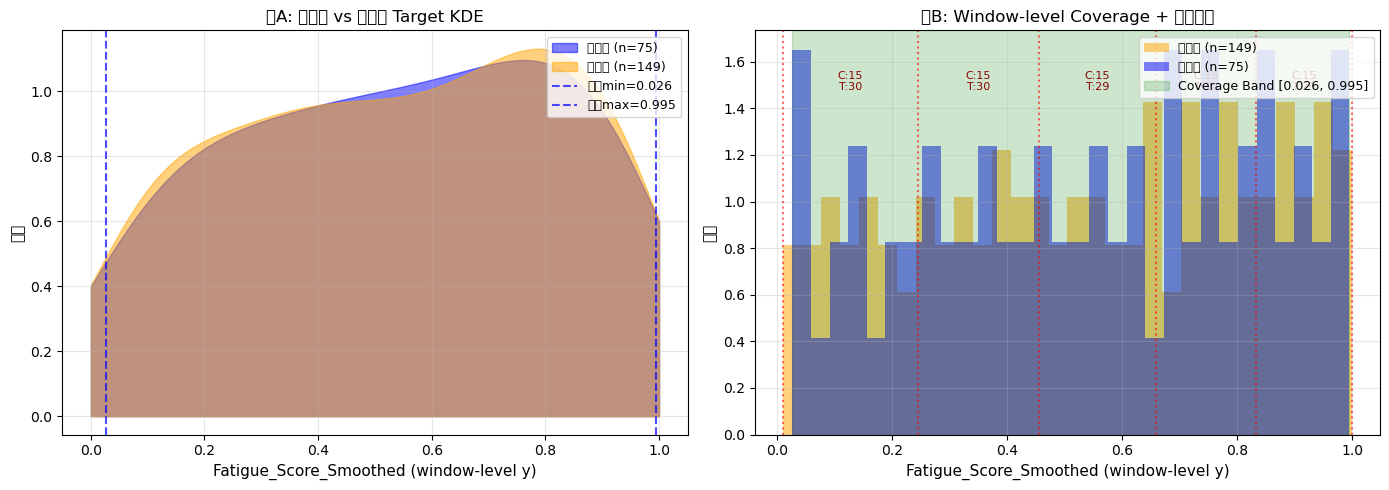


Gate检查 - 判断是否允许进行监督微调

【Gate-1】分布重叠检查:
  校准集覆盖范围: [0.0262, 0.9947]
  测试集95%区间: [0.0440, 0.9734]
  覆盖检查: 校准min(0.0262) <= 测试p2.5(0.0440)? True
           校准max(0.9947) >= 测试p97.5(0.9734)? True
  ✅ Gate-1 通过: 校准集覆盖测试集95%区间

【Gate-2】校准样本量检查:
  校准窗口总数: 75
  阈值: >= 100
  各层校准样本数: [15, 15, 15, 15, 15]
  最小层样本数: 15 (阈值: >= 15)
  ❌ Gate-2 失败: 样本量不足

🔴 Gate未通过 - 监督微调可能无效
   原因: 校准样本量不足


In [12]:
# === Cell 11: 诊断图 - KDE + Window-level Coverage + Gate检查 ===
print("="*60)
print("诊断图 - 分布覆盖分析 + Gate检查")
print("="*60)

from scipy.stats import gaussian_kde

# ============================================================
# 图A: KDE (校准窗口 y vs 测试窗口 y)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图A: KDE对比
ax1 = axes[0]
y_calib_kde = gaussian_kde(y_calib)
y_test_kde = gaussian_kde(y_test)
x_range = np.linspace(0, 1, 200)

ax1.fill_between(x_range, y_calib_kde(x_range), alpha=0.5, label=f'校准集 (n={len(y_calib)})', color='blue')
ax1.fill_between(x_range, y_test_kde(x_range), alpha=0.5, label=f'测试集 (n={len(y_test)})', color='orange')
ax1.axvline(y_calib.min(), color='blue', linestyle='--', alpha=0.7, label=f'校准min={y_calib.min():.3f}')
ax1.axvline(y_calib.max(), color='blue', linestyle='--', alpha=0.7, label=f'校准max={y_calib.max():.3f}')
ax1.set_xlabel('Fatigue_Score_Smoothed (window-level y)', fontsize=11)
ax1.set_ylabel('密度', fontsize=11)
ax1.set_title('图A: 校准集 vs 测试集 Target KDE', fontsize=12)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# 图B: Window-level coverage + 分层覆盖可视化
# ============================================================
ax2 = axes[1]

# 画测试集直方图 (底层)
ax2.hist(y_test, bins=30, alpha=0.5, label=f'测试集 (n={len(y_test)})', color='orange', density=True)
# 画校准集直方图 (叠加)
ax2.hist(y_calib, bins=30, alpha=0.5, label=f'校准集 (n={len(y_calib)})', color='blue', density=True)

# 画coverage band
coverage_min, coverage_max = y_calib.min(), y_calib.max()
ax2.axvspan(coverage_min, coverage_max, alpha=0.2, color='green', label=f'Coverage Band [{coverage_min:.3f}, {coverage_max:.3f}]')

# 画K个分位区间边界线
bin_edges = np.percentile(y_all, np.linspace(0, 100, K_BINS + 1))
for i, edge in enumerate(bin_edges):
    ax2.axvline(edge, color='red', linestyle=':', alpha=0.6)
    if i < len(bin_edges) - 1:
        # 统计该区间的校准/测试样本数
        mask_calib = (y_calib >= bin_edges[i]) & (y_calib < bin_edges[i+1])
        mask_test = (y_test >= bin_edges[i]) & (y_test < bin_edges[i+1])
        n_calib_bin = mask_calib.sum()
        n_test_bin = mask_test.sum()
        mid_y = (bin_edges[i] + bin_edges[i+1]) / 2
        ax2.text(mid_y, ax2.get_ylim()[1]*0.9, f'C:{n_calib_bin}\nT:{n_test_bin}', 
                ha='center', va='top', fontsize=8, color='darkred')

ax2.set_xlabel('Fatigue_Score_Smoothed (window-level y)', fontsize=11)
ax2.set_ylabel('密度', fontsize=11)
ax2.set_title('图B: Window-level Coverage + 分层覆盖', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('HFENN_distribution_aware_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Gate检查
# ============================================================
print("\n" + "="*60)
print("Gate检查 - 判断是否允许进行监督微调")
print("="*60)

# Gate-1: 分布重叠检查
test_p2_5 = np.percentile(y_test, 2.5)
test_p97_5 = np.percentile(y_test, 97.5)
coverage_covers_test = (coverage_min <= test_p2_5) and (coverage_max >= test_p97_5)

print(f"\n【Gate-1】分布重叠检查:")
print(f"  校准集覆盖范围: [{coverage_min:.4f}, {coverage_max:.4f}]")
print(f"  测试集95%区间: [{test_p2_5:.4f}, {test_p97_5:.4f}]")
print(f"  覆盖检查: 校准min({coverage_min:.4f}) <= 测试p2.5({test_p2_5:.4f})? {coverage_min <= test_p2_5}")
print(f"           校准max({coverage_max:.4f}) >= 测试p97.5({test_p97_5:.4f})? {coverage_max >= test_p97_5}")

if coverage_covers_test:
    print(f"  ✅ Gate-1 通过: 校准集覆盖测试集95%区间")
    gate1_pass = True
else:
    # 检查覆盖比例
    test_in_coverage = ((y_test >= coverage_min) & (y_test <= coverage_max)).mean()
    print(f"  ⚠️ 校准集覆盖测试集 {test_in_coverage*100:.1f}% 的样本")
    if test_in_coverage >= 0.80:
        print(f"  ✅ Gate-1 通过 (宽松): 覆盖率 >= 80%")
        gate1_pass = True
    else:
        print(f"  ❌ Gate-1 失败: 覆盖率 < 80%，监督微调可能无效")
        gate1_pass = False

# Gate-2: 校准样本量检查
print(f"\n【Gate-2】校准样本量检查:")
print(f"  校准窗口总数: {len(y_calib)}")
print(f"  阈值: >= 100")

# 检查每层样本数
bin_sample_counts = []
for bin_id in sorted(window_df['bin'].unique()):
    n_in_bin = ((y_calib >= bin_edges[bin_id]) & (y_calib < bin_edges[bin_id+1])).sum() if bin_id < K_BINS-1 else \
               ((y_calib >= bin_edges[bin_id]) & (y_calib <= bin_edges[bin_id+1])).sum()
    bin_sample_counts.append(n_in_bin)
    
print(f"  各层校准样本数: {bin_sample_counts}")
min_bin_samples = min(bin_sample_counts)
print(f"  最小层样本数: {min_bin_samples} (阈值: >= {MIN_SAMPLES_PER_BIN})")

if len(y_calib) >= 100 and min_bin_samples >= MIN_SAMPLES_PER_BIN:
    print(f"  ✅ Gate-2 通过: 样本量充足")
    gate2_pass = True
else:
    print(f"  ❌ Gate-2 失败: 样本量不足")
    gate2_pass = False

# 最终Gate结果
print(f"\n" + "="*60)
if gate1_pass and gate2_pass:
    print("🟢 所有Gate通过 - 允许进行监督微调")
    ALLOW_FINETUNE = True
else:
    print("🔴 Gate未通过 - 监督微调可能无效")
    if not gate1_pass:
        print("   原因: 校准集分布未覆盖测试集")
    if not gate2_pass:
        print("   原因: 校准样本量不足")
    ALLOW_FINETUNE = False
print("="*60)

In [13]:
# === Cell 12: 时间特征 + 累积负荷特征 + y_base状态特征 ===
print("="*60)
print("添加时间感知特征 (时间进度 + 累积负荷 + y_base状态)")
print("="*60)

# ============================================================
# 配置参数
# ============================================================
ROLLING_WINDOW = 10  # 滚动窗口大小 (过去10个窗口)

# ============================================================
# 辅助函数：计算滚动特征
# ============================================================
def compute_rolling_features(values, window_indices, rolling_window=10):
    """
    计算滚动特征 (rolling mean, rolling slope)
    
    参数:
        values: 每个窗口的值 (如Pulse均值或y_base预测)
        window_indices: 窗口在session中的索引 (用于确定时间顺序)
        rolling_window: 滚动窗口大小
    
    返回:
        rolling_mean: 滚动均值
        rolling_slope: 滚动斜率 (线性回归斜率)
    """
    n = len(values)
    rolling_mean = np.zeros(n)
    rolling_slope = np.zeros(n)
    
    for i in range(n):
        # 获取当前窗口之前的窗口 (按window_idx排序)
        start_idx = max(0, i - rolling_window + 1)
        window_values = values[start_idx:i+1]
        
        # 滚动均值
        rolling_mean[i] = np.mean(window_values)
        
        # 滚动斜率 (简单线性回归)
        if len(window_values) >= 2:
            x = np.arange(len(window_values))
            slope = np.polyfit(x, window_values, 1)[0]
            rolling_slope[i] = slope
        else:
            rolling_slope[i] = 0
    
    return rolling_mean, rolling_slope

# ============================================================
# Step 1: 计算时间进度特征 (t = window_idx / total_windows)
# ============================================================
print("\n【Step 1】计算时间进度特征...")

# 对所有窗口计算时间进度
t_progress_all = window_idx_all / (n_total_windows - 1) if n_total_windows > 1 else np.zeros(n_total_windows)

# 分离校准集和测试集的时间进度
t_progress_calib = t_progress_all[calib_indices]
t_progress_test = t_progress_all[test_indices]

print(f"  时间进度范围: [{t_progress_all.min():.4f}, {t_progress_all.max():.4f}]")
print(f"  校准集时间进度: [{t_progress_calib.min():.4f}, {t_progress_calib.max():.4f}]")
print(f"  测试集时间进度: [{t_progress_test.min():.4f}, {t_progress_test.max():.4f}]")

# ============================================================
# Step 2: 计算Pulse累积负荷特征 (rolling mean + rolling slope)
# ============================================================
print(f"\n【Step 2】计算Pulse累积负荷特征 (过去{ROLLING_WINDOW}个窗口)...")

# 计算每个窗口的Pulse均值 (作为负荷指标)
pulse_window_mean_all = np.array([seg.mean() for seg in X_pulse_all])

# 计算滚动特征 (对所有窗口，按时间顺序)
pulse_rolling_mean_all, pulse_rolling_slope_all = compute_rolling_features(
    pulse_window_mean_all, window_idx_all, ROLLING_WINDOW)

# 分离校准集和测试集
pulse_rolling_mean_calib = pulse_rolling_mean_all[calib_indices]
pulse_rolling_slope_calib = pulse_rolling_slope_all[calib_indices]
pulse_rolling_mean_test = pulse_rolling_mean_all[test_indices]
pulse_rolling_slope_test = pulse_rolling_slope_all[test_indices]

print(f"  Pulse滚动均值范围: [{pulse_rolling_mean_all.min():.4f}, {pulse_rolling_mean_all.max():.4f}]")
print(f"  Pulse滚动斜率范围: [{pulse_rolling_slope_all.min():.4f}, {pulse_rolling_slope_all.max():.4f}]")

# ============================================================
# Step 3: 对训练集计算相同的特征
# ============================================================
print("\n【Step 3】对训练集计算时间特征和累积负荷...")

# 训练集需要按参与者分组计算
def compute_features_by_participant(X_pulse, pids, window_indices, rolling_window=10):
    """按参与者分组计算时间进度和滚动特征"""
    n = len(X_pulse)
    t_progress = np.zeros(n)
    pulse_rolling_mean = np.zeros(n)
    pulse_rolling_slope = np.zeros(n)
    
    for pid in np.unique(pids):
        mask = pids == pid
        indices = np.where(mask)[0]
        
        # 该参与者的窗口数
        n_windows_pid = len(indices)
        
        # 时间进度
        win_idx_pid = window_indices[mask]
        t_progress[mask] = win_idx_pid / (n_windows_pid - 1) if n_windows_pid > 1 else 0
        
        # Pulse均值
        pulse_means_pid = np.array([X_pulse[i].mean() for i in indices])
        
        # 滚动特征
        rm, rs = compute_rolling_features(pulse_means_pid, win_idx_pid, rolling_window)
        pulse_rolling_mean[mask] = rm
        pulse_rolling_slope[mask] = rs
    
    return t_progress, pulse_rolling_mean, pulse_rolling_slope

t_progress_train, pulse_rolling_mean_train, pulse_rolling_slope_train = compute_features_by_participant(
    X_pulse_train, pids_train, window_idx_train, ROLLING_WINDOW)

print(f"  训练集时间进度范围: [{t_progress_train.min():.4f}, {t_progress_train.max():.4f}]")
print(f"  训练集Pulse滚动均值范围: [{pulse_rolling_mean_train.min():.4f}, {pulse_rolling_mean_train.max():.4f}]")

# ============================================================
# Step 4: 组装时间感知特征向量
# ============================================================
print("\n【Step 4】组装时间感知特征向量...")

# 训练集时间特征 (3维: t_progress, pulse_rolling_mean, pulse_rolling_slope)
temporal_features_train = np.column_stack([
    t_progress_train,
    pulse_rolling_mean_train,
    pulse_rolling_slope_train
])

# 校准集时间特征
temporal_features_calib = np.column_stack([
    t_progress_calib,
    pulse_rolling_mean_calib,
    pulse_rolling_slope_calib
])

# 测试集时间特征
temporal_features_test = np.column_stack([
    t_progress_test,
    pulse_rolling_mean_test,
    pulse_rolling_slope_test
])

print(f"  时间特征维度: {temporal_features_train.shape[1]}")
print(f"  训练集: {temporal_features_train.shape}")
print(f"  校准集: {temporal_features_calib.shape}")
print(f"  测试集: {temporal_features_test.shape}")

# ============================================================
# Step 5: 将时间特征与原始特征合并
# ============================================================
print("\n【Step 5】将时间特征与原始特征合并...")

X_features_train_with_temporal = np.hstack([X_features_train, temporal_features_train])
X_features_calib_with_temporal = np.hstack([X_features_calib, temporal_features_calib])
X_features_test_with_temporal = np.hstack([X_features_test, temporal_features_test])

print(f"  合并后特征维度: {X_features_train_with_temporal.shape[1]}")
print(f"  (原始特征: {X_features_train.shape[1]} + 时间特征: {temporal_features_train.shape[1]})")

# 更新特征变量名 (后续Cell使用)
X_features_train_original = X_features_train.copy()
X_features_calib_original = X_features_calib.copy()
X_features_test_original = X_features_test.copy()

X_features_train = X_features_train_with_temporal
X_features_calib = X_features_calib_with_temporal
X_features_test = X_features_test_with_temporal

print("\n✅ 时间感知特征添加完成")
print(f"  新增特征: t_progress, pulse_rolling_mean, pulse_rolling_slope")
print(f"  总特征维度: {X_features_train.shape[1]}")

添加时间感知特征 (时间进度 + 累积负荷 + y_base状态)

【Step 1】计算时间进度特征...
  时间进度范围: [0.0000, 1.0000]
  校准集时间进度: [0.0135, 0.9955]
  测试集时间进度: [0.0000, 1.0000]

【Step 2】计算Pulse累积负荷特征 (过去10个窗口)...
  Pulse滚动均值范围: [-0.0304, 0.0101]
  Pulse滚动斜率范围: [-0.0147, 0.0061]

【Step 3】对训练集计算时间特征和累积负荷...
  训练集时间进度范围: [0.0000, 1.0000]
  训练集Pulse滚动均值范围: [-1.0398, 0.3912]

【Step 4】组装时间感知特征向量...
  时间特征维度: 3
  训练集: (2931, 3)
  校准集: (75, 3)
  测试集: (149, 3)

【Step 5】将时间特征与原始特征合并...
  合并后特征维度: 124
  (原始特征: 121 + 时间特征: 3)

✅ 时间感知特征添加完成
  新增特征: t_progress, pulse_rolling_mean, pulse_rolling_slope
  总特征维度: 124


In [14]:
# === Cell 12: 校准集内部分割 (分层采样版) ===
print("校准集内部分割...")

n_calib_total = len(y_calib)
n_calib_val = int(n_calib_total * CALIB_VAL_SPLIT)
n_calib_train = n_calib_total - n_calib_val

# 为了保持分层特性，按target排序后均匀抽取验证集
# 这样验证集也能覆盖全范围
calib_sorted_idx = np.argsort(y_calib)
val_step = n_calib_total // n_calib_val if n_calib_val > 0 else n_calib_total
val_indices_in_calib = calib_sorted_idx[::val_step][:n_calib_val]
train_indices_in_calib = np.array([i for i in range(n_calib_total) if i not in val_indices_in_calib])

# 校准训练集
X_pulse_calib_train = X_pulse_calib[train_indices_in_calib]
X_fatigue_calib_train = X_fatigue_calib[train_indices_in_calib]
X_features_calib_train = X_features_calib[train_indices_in_calib]
y_calib_train = y_calib[train_indices_in_calib]

# 校准验证集
X_pulse_calib_val = X_pulse_calib[val_indices_in_calib]
X_fatigue_calib_val = X_fatigue_calib[val_indices_in_calib]
X_features_calib_val = X_features_calib[val_indices_in_calib]
y_calib_val = y_calib[val_indices_in_calib]

print(f"校准训练集: {len(y_calib_train)} 样本")
print(f"  Target范围: [{y_calib_train.min():.4f}, {y_calib_train.max():.4f}]")
print(f"校准验证集: {len(y_calib_val)} 样本")
print(f"  Target范围: [{y_calib_val.min():.4f}, {y_calib_val.max():.4f}]")
print(f"最终测试集: {len(y_test)} 样本")
print(f"  Target范围: [{y_test.min():.4f}, {y_test.max():.4f}]")

# 验证分层特性
print(f"\n✅ 分层验证:")
print(f"  校准训练集覆盖: [{y_calib_train.min():.4f}, {y_calib_train.max():.4f}]")
print(f"  校准验证集覆盖: [{y_calib_val.min():.4f}, {y_calib_val.max():.4f}]")
print(f"  两者都应覆盖全范围，确保验证集能有效监控过拟合")

校准集内部分割...
校准训练集: 60 样本
  Target范围: [0.0314, 0.9947]
校准验证集: 15 样本
  Target范围: [0.0262, 0.9537]
最终测试集: 149 样本
  Target范围: [0.0105, 0.9984]

✅ 分层验证:
  校准训练集覆盖: [0.0314, 0.9947]
  校准验证集覆盖: [0.0262, 0.9537]
  两者都应覆盖全范围，确保验证集能有效监控过拟合


In [15]:
# === Cell 12: 特征处理和小波变换 ===
print("特征处理和小波变换...")

# 特征平滑
print("应用特征平滑...")
X_features_train_smooth = apply_feature_smoothing(X_features_train)
X_features_calib_train_smooth = apply_feature_smoothing(X_features_calib_train)
X_features_calib_val_smooth = apply_feature_smoothing(X_features_calib_val)
X_features_test_smooth = apply_feature_smoothing(X_features_test)

# 检查并处理NaN值
def handle_nan_features(X, name=""):
    """处理特征中的NaN和Inf值"""
    nan_count = np.isnan(X).sum()
    inf_count = np.isinf(X).sum()
    if nan_count > 0 or inf_count > 0:
        print(f"  ⚠️ {name}: 发现 {nan_count} 个NaN, {inf_count} 个Inf，用0填充")
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

X_features_train_smooth = handle_nan_features(X_features_train_smooth, "训练集特征")
X_features_calib_train_smooth = handle_nan_features(X_features_calib_train_smooth, "校准训练集特征")
X_features_calib_val_smooth = handle_nan_features(X_features_calib_val_smooth, "校准验证集特征")
X_features_test_smooth = handle_nan_features(X_features_test_smooth, "测试集特征")

# 特征标准化 (只在训练集fit)
print("特征标准化...")
feature_scaler = StandardScaler()
X_features_train_scaled = feature_scaler.fit_transform(X_features_train_smooth)
X_features_calib_train_scaled = feature_scaler.transform(X_features_calib_train_smooth)
X_features_calib_val_scaled = feature_scaler.transform(X_features_calib_val_smooth)
X_features_test_scaled = feature_scaler.transform(X_features_test_smooth)

# 标准化后再次检查NaN (std=0的列会产生NaN)
X_features_train_scaled = handle_nan_features(X_features_train_scaled, "标准化后训练集")
X_features_calib_train_scaled = handle_nan_features(X_features_calib_train_scaled, "标准化后校准训练集")
X_features_calib_val_scaled = handle_nan_features(X_features_calib_val_scaled, "标准化后校准验证集")
X_features_test_scaled = handle_nan_features(X_features_test_scaled, "标准化后测试集")

# 特征选择 (只在训练集fit)
print("特征选择...")
n_selected = min(50, X_features_train_scaled.shape[1])
feature_selector = SelectKBest(f_regression, k=n_selected)
X_features_train_selected = feature_selector.fit_transform(X_features_train_scaled, y_train)
X_features_calib_train_selected = feature_selector.transform(X_features_calib_train_scaled)
X_features_calib_val_selected = feature_selector.transform(X_features_calib_val_scaled)
X_features_test_selected = feature_selector.transform(X_features_test_scaled)

print(f"选择特征数: {n_selected}")

# 小波变换
print("\n应用小波变换...")
# 训练集
X_pulse_train_wt = apply_wavelet_transform(X_pulse_train)
X_fatigue_train_wt = apply_wavelet_transform(X_fatigue_train)

# 计算差分信号的小波变换
X_pulse_diff_train = np.diff(X_pulse_train, axis=1)
X_fatigue_diff_train = np.diff(X_fatigue_train, axis=1)
X_pulse_diff_train_wt = apply_wavelet_transform(X_pulse_diff_train)
X_fatigue_diff_train_wt = apply_wavelet_transform(X_fatigue_diff_train)

# 校准训练集
X_pulse_calib_train_wt = apply_wavelet_transform(X_pulse_calib_train)
X_fatigue_calib_train_wt = apply_wavelet_transform(X_fatigue_calib_train)
X_pulse_diff_calib_train = np.diff(X_pulse_calib_train, axis=1)
X_fatigue_diff_calib_train = np.diff(X_fatigue_calib_train, axis=1)
X_pulse_diff_calib_train_wt = apply_wavelet_transform(X_pulse_diff_calib_train)
X_fatigue_diff_calib_train_wt = apply_wavelet_transform(X_fatigue_diff_calib_train)

# 校准验证集
X_pulse_calib_val_wt = apply_wavelet_transform(X_pulse_calib_val)
X_fatigue_calib_val_wt = apply_wavelet_transform(X_fatigue_calib_val)
X_pulse_diff_calib_val = np.diff(X_pulse_calib_val, axis=1)
X_fatigue_diff_calib_val = np.diff(X_fatigue_calib_val, axis=1)
X_pulse_diff_calib_val_wt = apply_wavelet_transform(X_pulse_diff_calib_val)
X_fatigue_diff_calib_val_wt = apply_wavelet_transform(X_fatigue_diff_calib_val)

# 测试集
X_pulse_test_wt = apply_wavelet_transform(X_pulse_test)
X_fatigue_test_wt = apply_wavelet_transform(X_fatigue_test)
X_pulse_diff_test = np.diff(X_pulse_test, axis=1)
X_fatigue_diff_test = np.diff(X_fatigue_test, axis=1)
X_pulse_diff_test_wt = apply_wavelet_transform(X_pulse_diff_test)
X_fatigue_diff_test_wt = apply_wavelet_transform(X_fatigue_diff_test)

print(f"Pulse小波特征维度: {X_pulse_train_wt.shape[1]}")
print(f"Fatigue小波特征维度: {X_fatigue_train_wt.shape[1]}")

# 添加通道维度
X_pulse_train_wt = X_pulse_train_wt[..., np.newaxis]
X_fatigue_train_wt = X_fatigue_train_wt[..., np.newaxis]
X_pulse_diff_train_wt = X_pulse_diff_train_wt[..., np.newaxis]
X_fatigue_diff_train_wt = X_fatigue_diff_train_wt[..., np.newaxis]

X_pulse_calib_train_wt = X_pulse_calib_train_wt[..., np.newaxis]
X_fatigue_calib_train_wt = X_fatigue_calib_train_wt[..., np.newaxis]
X_pulse_diff_calib_train_wt = X_pulse_diff_calib_train_wt[..., np.newaxis]
X_fatigue_diff_calib_train_wt = X_fatigue_diff_calib_train_wt[..., np.newaxis]

X_pulse_calib_val_wt = X_pulse_calib_val_wt[..., np.newaxis]
X_fatigue_calib_val_wt = X_fatigue_calib_val_wt[..., np.newaxis]
X_pulse_diff_calib_val_wt = X_pulse_diff_calib_val_wt[..., np.newaxis]
X_fatigue_diff_calib_val_wt = X_fatigue_diff_calib_val_wt[..., np.newaxis]

X_pulse_test_wt = X_pulse_test_wt[..., np.newaxis]
X_fatigue_test_wt = X_fatigue_test_wt[..., np.newaxis]
X_pulse_diff_test_wt = X_pulse_diff_test_wt[..., np.newaxis]
X_fatigue_diff_test_wt = X_fatigue_diff_test_wt[..., np.newaxis]

print("\n✅ 特征处理和小波变换完成")

特征处理和小波变换...
应用特征平滑...
  ⚠️ 训练集特征: 发现 788 个NaN, 0 个Inf，用0填充
  ⚠️ 测试集特征: 发现 72 个NaN, 0 个Inf，用0填充
特征标准化...
特征选择...
选择特征数: 50

应用小波变换...
Pulse小波特征维度: 2635
Fatigue小波特征维度: 2635

✅ 特征处理和小波变换完成


In [16]:
# === Cell 13: 构建并训练Base Model (优化：按参与者分层划分验证集) ===
print("="*60)
print("Step 1: 训练Base Model (排除测试参与者)")
print("="*60)

# 获取模型输入维度
pulse_wavelet_dim = X_pulse_train_wt.shape[1]
fatigue_wavelet_dim = X_fatigue_train_wt.shape[1]
pulse_diff_wavelet_dim = X_pulse_diff_train_wt.shape[1]
fatigue_diff_wavelet_dim = X_fatigue_diff_train_wt.shape[1]

print(f"\n模型输入维度:")
print(f"  Pulse小波: {pulse_wavelet_dim}")
print(f"  Fatigue小波: {fatigue_wavelet_dim}")
print(f"  增强特征: {n_selected}")

# ============================================================
# 优化：按参与者分层划分验证集，确保训练/验证集参与者分布均匀
# ============================================================
from sklearn.model_selection import train_test_split

# 按参与者分层划分 (stratify by participant)
val_ratio = 0.15
indices = np.arange(len(y_train))

# 使用pids_train进行分层
train_idx, val_idx = train_test_split(
    indices, 
    test_size=val_ratio, 
    random_state=42,
    stratify=pids_train  # 按参与者分层
)

print(f"\nBase Model 训练/验证集划分 (按参与者分层):")
print(f"  训练样本: {len(train_idx)}")
print(f"  验证样本: {len(val_idx)}")

# 验证分层效果
train_pids_dist = dict(zip(*np.unique(pids_train[train_idx], return_counts=True)))
val_pids_dist = dict(zip(*np.unique(pids_train[val_idx], return_counts=True)))
print(f"  训练集参与者数: {len(train_pids_dist)}")
print(f"  验证集参与者数: {len(val_pids_dist)}")

# 划分数据
X_pulse_train_wt_tr = X_pulse_train_wt[train_idx]
X_fatigue_train_wt_tr = X_fatigue_train_wt[train_idx]
X_pulse_diff_train_wt_tr = X_pulse_diff_train_wt[train_idx]
X_fatigue_diff_train_wt_tr = X_fatigue_diff_train_wt[train_idx]
X_features_train_selected_tr = X_features_train_selected[train_idx]
y_train_tr = y_train[train_idx]

X_pulse_train_wt_val = X_pulse_train_wt[val_idx]
X_fatigue_train_wt_val = X_fatigue_train_wt[val_idx]
X_pulse_diff_train_wt_val = X_pulse_diff_train_wt[val_idx]
X_fatigue_diff_train_wt_val = X_fatigue_diff_train_wt[val_idx]
X_features_train_selected_val = X_features_train_selected[val_idx]
y_train_val = y_train[val_idx]

# 构建模型
model = build_hfenn_model(
    pulse_wavelet_dim=pulse_wavelet_dim,
    fatigue_wavelet_dim=fatigue_wavelet_dim,
    enhanced_feature_dim=X_features_train_selected.shape[1],
    n_selected_features=n_selected
)

# 确保所有层可训练
model = unfreeze_all(model)

# 编译模型
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# 准备训练输入
train_inputs_tr = [
    X_pulse_train_wt_tr,
    X_fatigue_train_wt_tr,
    X_pulse_diff_train_wt_tr,
    X_fatigue_diff_train_wt_tr,
    X_features_train_selected_tr
]

train_inputs_val = [
    X_pulse_train_wt_val,
    X_fatigue_train_wt_val,
    X_pulse_diff_train_wt_val,
    X_fatigue_diff_train_wt_val,
    X_features_train_selected_val
]

# 回调函数
callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# 训练Base Model
print("\n开始训练Base Model...")
history_base = model.fit(
    train_inputs_tr,
    y_train_tr,
    epochs=100,
    batch_size=32,
    validation_data=(train_inputs_val, y_train_val),
    callbacks=callbacks_base,
    verbose=1
)

print("\n✅ Base Model训练完成")

Step 1: 训练Base Model (排除测试参与者)

模型输入维度:
  Pulse小波: 2635
  Fatigue小波: 2635
  增强特征: 50

Base Model 训练/验证集划分 (按参与者分层):
  训练样本: 2491
  验证样本: 440
  训练集参与者数: 12
  验证集参与者数: 12


Model: "HFENN_Regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ pulse_wavelet_input           │ (None, 2635, 1)           │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fatigue_wavelet_input         │ (None, 2635, 1)           │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pulse_diff_wavelet_input      │ (None, 2635, 1)           │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fatigue_diff_wavelet_input    │ (None, 2635, 1)           │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pulse_block1_conv1 (Conv1D)   │ (None, 2635, 64)          │             256 │ pulse_wavelet_input[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fatigue_block1_conv1 (Conv1D) │ (None, 2635, 64)          │             256 │ fatigue_wavelet_input[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pulse_diff_block1_conv1       │ (None, 2635, 64)          │             256 │ pulse_diff_wavelet_input[… │
│ (Conv1D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fatigue_diff_block1_conv1     │ (None, 2635, 64)          │             256 │ fatigue_diff_wavelet_inpu… │
│ (Conv1D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pulse_block1_conv2 (Conv1D)   │ (None, 2635, 64)          │          12,352 │ pulse_block1_conv1[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fatigue_block1_conv2 (Conv1D) │ (None, 2635, 64)          │          12,352 │ fatigue_block1_conv1[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pulse_diff_block1_conv2       │ (None, 2635, 64)          │          12,352 │ pulse_diff_block1_conv1[0… │
│ (Conv1D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fatigue_diff_block1_conv2     │ (None, 2635, 64)          │          12,352 │ fatigue_diff_block1_conv1… │
│ (Conv1D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pulse_block1_gap              │ (None, 64)                │               0 │ pulse_block1_conv2[0][0]   │
│ (GlobalAveragePooling1D)      │                           │               

 Total params: 610,209 (2.33 MB)

 Trainable params: 610,209 (2.33 MB)

 Non-trainable params: 0 (0.00 B)


开始训练Base Model...
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - loss: 0.0575 - mae: 0.1970 - val_loss: 0.0120 - val_mae: 0.0779 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 223ms/step - loss: 0.0130 - mae: 0.0860 - val_loss: 0.0068 - val_mae: 0.0542 - learning_rate: 0.0010
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 225ms/step - loss: 0.0098 - mae: 0.0739 - val_loss: 0.0059 - val_mae: 0.0473 - learning_rate: 0.0010
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 224ms/step - loss: 0.0068 - mae: 0.0628 - val_loss: 0.0043 - val_mae: 0.0387 - learning_rate: 0.0010
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step - loss: 0.0055 - mae: 0.0581 - val_loss: 0.0046 - val_mae: 0.0435 - learning_rate: 0.0010
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 224ms/step - loss: 0.0056 - mae: 0.0545 - val_loss: 0.0035 - val_mae: 0.0361 - learning_rate: 0.0010
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 224ms/step - loss: 0.0046 - mae: 0.0494 - val_loss: 0.0042 - val_mae: 0.04

In [17]:
# === Cell 14: 评估Base Model在测试集上的性能 (微调前) ===
print("="*60)
print("Step 2: 评估Base Model (微调前)")
print("="*60)

# 准备测试输入
test_inputs = [
    X_pulse_test_wt,
    X_fatigue_test_wt,
    X_pulse_diff_test_wt,
    X_fatigue_diff_test_wt,
    X_features_test_selected
]

# 预测
y_pred_base = model.predict(test_inputs, verbose=0).flatten()

# 计算指标
mse_base = mean_squared_error(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, y_pred_base)

print(f"\nBase Model 在测试集上的性能 (微调前):")
print(f"  MSE:  {mse_base:.6f}")
print(f"  MAE:  {mae_base:.6f}")
print(f"  RMSE: {rmse_base:.6f}")
print(f"  R²:   {r2_base:.6f}")

# 保存Base Model权重用于后续比较
base_model_weights = model.get_weights()

Step 2: 评估Base Model (微调前)

Base Model 在测试集上的性能 (微调前):
  MSE:  0.007020
  MAE:  0.068917
  RMSE: 0.083785
  R²:   0.914562


In [18]:
# === Cell 15: Stage A - 只训练输出层 (极简微调) ===
print("="*60)
print("Step 3: Stage A 微调 - 极简版 (只训练输出层)")
print("="*60)

# 冻结特征提取层，只保留输出层可训练
model = freeze_feature_extraction_layers(model)

# 重新编译 (使用更小的学习率，防止破坏Base Model)
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 降低学习率: 1e-4 -> 1e-5
    loss='mse',
    metrics=['mae']
)

# 准备校准训练和验证输入
calib_train_inputs = [
    X_pulse_calib_train_wt,
    X_fatigue_calib_train_wt,
    X_pulse_diff_calib_train_wt,
    X_fatigue_diff_calib_train_wt,
    X_features_calib_train_selected
]

calib_val_inputs = [
    X_pulse_calib_val_wt,
    X_fatigue_calib_val_wt,
    X_pulse_diff_calib_val_wt,
    X_fatigue_diff_calib_val_wt,
    X_features_calib_val_selected
]

# 回调函数 (更保守的早停策略)
callbacks_stage_a = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
]

# Stage A 微调
print(f"\n校准训练集: {len(y_calib_train)} 样本")
print(f"校准验证集: {len(y_calib_val)} 样本")
print("\n开始Stage A微调 (极简版)...")

history_stage_a = model.fit(
    calib_train_inputs,
    y_calib_train,
    epochs=10,  # 减少epoch: 20 -> 10
    batch_size=min(16, len(y_calib_train)),  # 小batch size
    validation_data=(calib_val_inputs, y_calib_val),
    callbacks=callbacks_stage_a,
    verbose=1
)

# 评估Stage A结果
y_pred_stage_a = model.predict(test_inputs, verbose=0).flatten()
mse_stage_a = mean_squared_error(y_test, y_pred_stage_a)
mae_stage_a = mean_absolute_error(y_test, y_pred_stage_a)
rmse_stage_a = np.sqrt(mse_stage_a)
r2_stage_a = r2_score(y_test, y_pred_stage_a)

print(f"\nStage A 微调后性能:")
print(f"  MSE:  {mse_stage_a:.6f}")
print(f"  MAE:  {mae_stage_a:.6f}")
print(f"  RMSE: {rmse_stage_a:.6f}")
print(f"  R²:   {r2_stage_a:.6f}")

# 计算提升
r2_improvement_a = r2_stage_a - r2_base
print(f"\n  R² 提升: {r2_improvement_a:+.6f}")

if r2_improvement_a >= 0:
    print("  ✅ 微调带来正向提升!")
else:
    print("  ⚠️ 微调未带来提升，但极简策略应减少性能下降幅度")

# 保存Stage A权重
stage_a_weights = model.get_weights()

Step 3: Stage A 微调 - 极简版 (只训练输出层)
  Stage A 冻结策略 (极简版):
    冻结层数: 103
    可训练层数: 1
    可训练层: ['regression_output']
    可训练参数量: 33
    参数/样本比: 约 1.9:1 (目标<10:1)

校准训练集: 60 样本
校准验证集: 15 样本

开始Stage A微调 (极简版)...
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0128 - mae: 0.0888 - val_loss: 0.0241 - val_mae: 0.1110 - learning_rate: 1.0000e-05
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0106 - mae: 0.0835 - val_loss: 0.0241 - val_mae: 0.1110 - learning_rate: 1.0000e-05
Epoch 3/10
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0095 - mae: 0.0786
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0110 - mae: 0.0817 - val_loss: 0.0240 - val_mae: 0.1110 - learning_rate: 1.0000e-05
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0112 - mae: 0.0827 - val_loss: 0.0240 - val_mae: 0.1110 - learning_rate: 5.0000e-06
Epoch 5/10
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0157 - mae: 0.10

In [19]:
# === Cell 16: Stage B - 训练回归头 (保守微调，可选) ===
print("="*60)
print("Step 4: Stage B 微调 - 训练回归头 (可选)")
print("="*60)

# 判断是否需要Stage B
STAGE_B_THRESHOLD = 0.02  # 降低阈值：如果Stage A提升小于此值，尝试Stage B

if r2_improvement_a < STAGE_B_THRESHOLD:
    print(f"\nStage A R²提升 ({r2_improvement_a:.4f}) < 阈值 ({STAGE_B_THRESHOLD})")
    print("执行Stage B: 训练回归头...")
    
    # 从Stage A权重开始
    model.set_weights(stage_a_weights)
    
    # 解冻回归头 (3层)
    model = unfreeze_fusion_layers(model)
    
    # 重新编译 (极小LR)
    model.compile(
        optimizer=Adam(learning_rate=1e-6),  # 更小的学习率
        loss='mse',
        metrics=['mae']
    )
    
    # 回调函数
    callbacks_stage_b = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8, verbose=1)
    ]
    
    # Stage B 微调
    print("\n开始Stage B微调 (保守版)...")
    history_stage_b = model.fit(
        calib_train_inputs,
        y_calib_train,
        epochs=5,  # 更少的epoch
        batch_size=min(16, len(y_calib_train)),
        validation_data=(calib_val_inputs, y_calib_val),
        callbacks=callbacks_stage_b,
        verbose=1
    )
    
    # 评估Stage B结果
    y_pred_stage_b = model.predict(test_inputs, verbose=0).flatten()
    mse_stage_b = mean_squared_error(y_test, y_pred_stage_b)
    mae_stage_b = mean_absolute_error(y_test, y_pred_stage_b)
    rmse_stage_b = np.sqrt(mse_stage_b)
    r2_stage_b = r2_score(y_test, y_pred_stage_b)
    
    print(f"\nStage B 微调后性能:")
    print(f"  MSE:  {mse_stage_b:.6f}")
    print(f"  MAE:  {mae_stage_b:.6f}")
    print(f"  RMSE: {rmse_stage_b:.6f}")
    print(f"  R²:   {r2_stage_b:.6f}")
    
    r2_improvement_b = r2_stage_b - r2_base
    print(f"\n  R² 总提升 (vs Base): {r2_improvement_b:+.6f}")
    
    # 选择最佳结果
    if r2_stage_b > r2_stage_a:
        best_stage = "Stage B"
        r2_final = r2_stage_b
        mse_final = mse_stage_b
        mae_final = mae_stage_b
        rmse_final = rmse_stage_b
        y_pred_final = y_pred_stage_b
    else:
        best_stage = "Stage A"
        r2_final = r2_stage_a
        mse_final = mse_stage_a
        mae_final = mae_stage_a
        rmse_final = rmse_stage_a
        y_pred_final = y_pred_stage_a
        model.set_weights(stage_a_weights)
else:
    print(f"\nStage A R²提升 ({r2_improvement_a:.4f}) >= 阈值 ({STAGE_B_THRESHOLD})")
    print("跳过Stage B")
    best_stage = "Stage A"
    r2_final = r2_stage_a
    mse_final = mse_stage_a
    mae_final = mae_stage_a
    rmse_final = rmse_stage_a
    y_pred_final = y_pred_stage_a
    r2_stage_b = None

print(f"\n✅ 最佳结果来自: {best_stage}")

Step 4: Stage B 微调 - 训练回归头 (可选)

Stage A R²提升 (0.0003) < 阈值 (0.02)
执行Stage B: 训练回归头...
  Stage B 解冻策略 (保守版):
    冻结层数: 101
    可训练层数: 3
    可训练层: ['regression_head_dense1', 'regression_head_dense2', 'regression_output']
    可训练参数量: 10,369

开始Stage B微调 (保守版)...
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - loss: 0.0125 - mae: 0.0850 - val_loss: 0.0240 - val_mae: 0.1109 - learning_rate: 1.0000e-06
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0151 - mae: 0.0942 - val_loss: 0.0240 - val_mae: 0.1109 - learning_rate: 1.0000e-06
Epoch 3/5
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0126 - mae: 0.0857
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0128 - mae: 0.0873 - val_loss: 0.0240 - val_mae: 0.1108 - learning_rate: 1.0000e-06
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0145 - mae: 0.1035 - val_loss: 0.0240 - val_mae: 0.1108 - learning_rate: 5.0000e-07
Epoch 5/5
3/4 ━━━━━━━━━━━━━

In [20]:
# === Cell 17: 结果汇总 (含DataFrame便于后续扩展) ===
print("="*60)
print("结果汇总")
print("="*60)

# 创建结果DataFrame (便于后续扩展到13个参与者)
results_df = pd.DataFrame({
    'Participant': [TEST_PARTICIPANT],
    'N_Train_Samples': [len(y_train)],
    'N_Calib_Train': [len(y_calib_train)],
    'N_Calib_Val': [len(y_calib_val)],
    'N_Test': [len(y_test)],
    'Base_MSE': [mse_base],
    'Base_MAE': [mae_base],
    'Base_RMSE': [rmse_base],
    'Base_R2': [r2_base],
    'StageA_MSE': [mse_stage_a],
    'StageA_MAE': [mae_stage_a],
    'StageA_RMSE': [rmse_stage_a],
    'StageA_R2': [r2_stage_a],
    'Final_MSE': [mse_final],
    'Final_MAE': [mae_final],
    'Final_RMSE': [rmse_final],
    'Final_R2': [r2_final],
    'Best_Stage': [best_stage],
    'R2_Improvement': [r2_final - r2_base]
})

# 打印汇总
print(f"\n测试参与者: {TEST_PARTICIPANT}")
print(f"校准集比例: {CALIBRATION_RATIO*100:.0f}%")
print(f"校准训练样本: {len(y_calib_train)}, 校准验证样本: {len(y_calib_val)}")
print(f"测试样本: {len(y_test)}")

print("\n" + "-"*70)
print(f"{'Stage':<25} {'MSE':>10} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("-"*70)
print(f"{'Base Model (微调前)':<25} {mse_base:>10.6f} {mae_base:>10.6f} {rmse_base:>10.6f} {r2_base:>10.6f}")
print(f"{'Stage A (回归头)':<25} {mse_stage_a:>10.6f} {mae_stage_a:>10.6f} {rmse_stage_a:>10.6f} {r2_stage_a:>10.6f}")
print(f"{f'最终 ({best_stage})':<25} {mse_final:>10.6f} {mae_final:>10.6f} {rmse_final:>10.6f} {r2_final:>10.6f}")
print("-"*70)

# 计算提升
r2_improvement_total = r2_final - r2_base
print(f"\n个性化微调带来的R²提升: {r2_improvement_total:+.6f}")

if r2_improvement_total > 0:
    print("✅ 个性化微调有效!")
else:
    print("⚠️ 个性化微调未带来提升，可能需要调整策略")

# 保存结果到CSV
results_df.to_csv(f'HFENN_personalized_{TEST_PARTICIPANT}_results.csv', index=False)
print(f"\n✅ 结果已保存至: HFENN_personalized_{TEST_PARTICIPANT}_results.csv")

# 显示DataFrame
print("\n结果DataFrame (便于后续汇总):")
display(results_df[['Participant', 'Base_R2', 'StageA_R2', 'Final_R2', 'R2_Improvement', 'Best_Stage']])

结果汇总

测试参与者: gs1
校准集比例: 30%
校准训练样本: 60, 校准验证样本: 15
测试样本: 149

----------------------------------------------------------------------
Stage                            MSE        MAE       RMSE         R²
----------------------------------------------------------------------
Base Model (微调前)            0.007020   0.068917   0.083785   0.914562
Stage A (回归头)               0.006999   0.068769   0.083658   0.914821
最终 (Stage B)                0.006982   0.068654   0.083559   0.915022
----------------------------------------------------------------------

个性化微调带来的R²提升: +0.000460
✅ 个性化微调有效!

✅ 结果已保存至: HFENN_personalized_gs1_results.csv

结果DataFrame (便于后续汇总):


,Participant,Base_R2,StageA_R2,Final_R2,R2_Improvement,Best_Stage
0,gs1,0.914562,0.914821,0.915022,0.00046,Stage B


生成可视化...


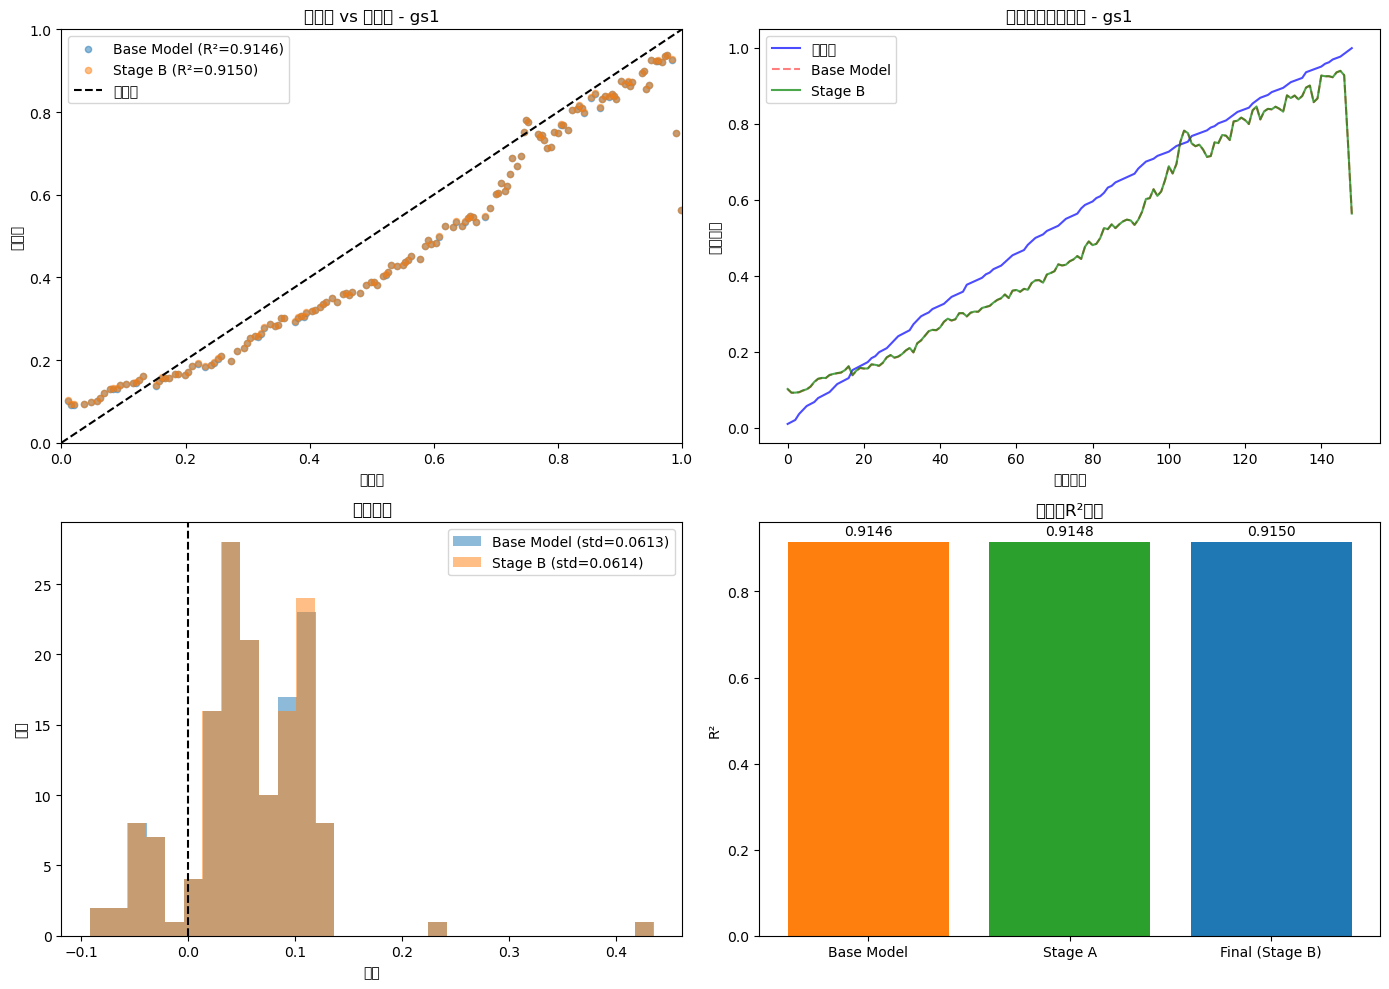


✅ 结果已保存至: HFENN_personalized_gs1_results.png


In [21]:
# === Cell 18: 可视化 ===
print("生成可视化...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 预测值 vs 真实值对比
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_base, alpha=0.5, label=f'Base Model (R²={r2_base:.4f})', s=20)
ax1.scatter(y_test, y_pred_final, alpha=0.5, label=f'{best_stage} (R²={r2_final:.4f})', s=20)
ax1.plot([0, 1], [0, 1], 'k--', label='理想线')
ax1.set_xlabel('真实值')
ax1.set_ylabel('预测值')
ax1.set_title(f'预测值 vs 真实值 - {TEST_PARTICIPANT}')
ax1.legend()
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# 2. 时间序列对比
ax2 = axes[0, 1]
time_axis = np.arange(len(y_test))
ax2.plot(time_axis, y_test, 'b-', label='真实值', alpha=0.7)
ax2.plot(time_axis, y_pred_base, 'r--', label='Base Model', alpha=0.5)
ax2.plot(time_axis, y_pred_final, 'g-', label=f'{best_stage}', alpha=0.7)
ax2.set_xlabel('样本索引')
ax2.set_ylabel('疲劳指数')
ax2.set_title(f'时间序列预测对比 - {TEST_PARTICIPANT}')
ax2.legend()

# 3. 残差分布
ax3 = axes[1, 0]
residuals_base = y_test - y_pred_base
residuals_final = y_test - y_pred_final
ax3.hist(residuals_base, bins=30, alpha=0.5, label=f'Base Model (std={np.std(residuals_base):.4f})')
ax3.hist(residuals_final, bins=30, alpha=0.5, label=f'{best_stage} (std={np.std(residuals_final):.4f})')
ax3.axvline(x=0, color='k', linestyle='--')
ax3.set_xlabel('残差')
ax3.set_ylabel('频数')
ax3.set_title('残差分布')
ax3.legend()

# 4. R²对比柱状图
ax4 = axes[1, 1]
stages = ['Base Model', 'Stage A', f'Final ({best_stage})']
r2_values = [r2_base, r2_stage_a, r2_final]
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax4.bar(stages, r2_values, color=colors)
ax4.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax4.set_ylabel('R²')
ax4.set_title('各阶段R²对比')
for bar, val in zip(bars, r2_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'HFENN_personalized_{TEST_PARTICIPANT}_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ 结果已保存至: HFENN_personalized_{TEST_PARTICIPANT}_results.png")

In [23]:
# === Cell 19: 诊断分析 - 验证个性化微调失效的根本原因 ===
print("="*70)
print("诊断分析 - 验证个性化微调失效的根本原因")
print("="*70)

# ============================================================
# 诊断1: 校准段 vs 测试段的 Target 分布
# ============================================================
print("\n" + "="*70)
print("【诊断1】校准段 vs 测试段的 Target (Fatigue_Score_Smoothed) 分布")
print("="*70)

# 校准段target统计
print(f"\n校准段 (前{CALIBRATION_RATIO*100:.0f}%, {len(y_calib)} 个窗口):")
print(f"  min:  {y_calib.min():.6f}")
print(f"  max:  {y_calib.max():.6f}")
print(f"  mean: {y_calib.mean():.6f}")
print(f"  std:  {y_calib.std():.6f}")

# 测试段target统计
print(f"\n测试段 (后{(1-CALIBRATION_RATIO)*100:.0f}%, {len(y_test)} 个窗口):")
print(f"  min:  {y_test.min():.6f}")
print(f"  max:  {y_test.max():.6f}")
print(f"  mean: {y_test.mean():.6f}")
print(f"  std:  {y_test.std():.6f}")

# 分布漂移分析
target_mean_shift = y_test.mean() - y_calib.mean()
target_std_ratio = y_test.std() / y_calib.std() if y_calib.std() > 0 else float('inf')
print(f"\n📊 Target分布漂移分析:")
print(f"  均值偏移: {target_mean_shift:+.6f} (测试段 - 校准段)")
print(f"  标准差比值: {target_std_ratio:.4f} (测试段 / 校准段)")

if abs(target_mean_shift) > 0.1:
    print(f"  ⚠️ 警告: 均值偏移较大，校准段学到的偏移可能对测试段无效")
if target_std_ratio > 1.5 or target_std_ratio < 0.67:
    print(f"  ⚠️ 警告: 标准差差异较大，测试段波动模式与校准段不同")

# ============================================================
# 诊断2: 标准化统计量对比 (校准段 vs 测试段原始数据)
# ============================================================
print("\n" + "="*70)
print("【诊断2】标准化统计量对比 - 检测分布漂移")
print("="*70)

# 校准段原始数据统计量 (用于标准化) - 使用std_stats (在Cell 9中定义)
print(f"\n校准段原始数据统计量 (用于标准化整个测试者数据):")
for col in ['Pulse', 'Fatigue']:
    mean_val = std_stats[TEST_PARTICIPANT][col]['mean']
    std_val = std_stats[TEST_PARTICIPANT][col]['std']
    print(f"  {col}: mean={mean_val:.6f}, std={std_val:.6f}")

# 测试段原始数据统计量 (使用df_test_participant代替df_test_raw)
n_calib_rows = int(len(df_test_participant) * STANDARDIZATION_RATIO)
df_test_raw_portion = df_test_participant.iloc[n_calib_rows:]  # 后70%原始数据

print(f"\n测试段原始数据统计量 (实际分布):")
for col in ['Pulse', 'Fatigue']:
    test_mean = df_test_raw_portion[col].mean()
    test_std = df_test_raw_portion[col].std()
    calib_mean = std_stats[TEST_PARTICIPANT][col]['mean']
    calib_std = std_stats[TEST_PARTICIPANT][col]['std']
    
    mean_shift = test_mean - calib_mean
    std_ratio = test_std / calib_std if calib_std > 0 else float('inf')
    
    print(f"  {col}: mean={test_mean:.6f}, std={test_std:.6f}")
    print(f"    → 均值偏移: {mean_shift:+.6f}, 标准差比值: {std_ratio:.4f}")
    
    if abs(mean_shift) > calib_std * 0.5:
        print(f"    ⚠️ 警告: {col} 均值偏移超过0.5个校准段标准差")
    if std_ratio > 1.3 or std_ratio < 0.77:
        print(f"    ⚠️ 警告: {col} 标准差差异超过30%")

# 标准化后的测试段数据分布 (使用df_test_participant_std)
df_test_std_portion = df_test_participant_std.iloc[n_calib_rows:]
print(f"\n标准化后测试段数据分布 (应该接近N(0,1)如果无漂移):")
for col in ['Pulse', 'Fatigue']:
    std_mean = df_test_std_portion[col].mean()
    std_std = df_test_std_portion[col].std()
    print(f"  {col}: mean={std_mean:.6f}, std={std_std:.6f}")
    if abs(std_mean) > 0.5 or abs(std_std - 1.0) > 0.3:
        print(f"    ⚠️ 警告: 标准化后分布偏离N(0,1)，存在分布漂移")

# ============================================================
# 诊断3: 微调前后权重变化量 (仅当变量存在时执行)
# ============================================================
print("\n" + "="*70)
print("【诊断3】微调前后 regression_output 层权重变化量")
print("="*70)

# 检查必要变量是否存在
if 'base_weights' not in dir() or 'stage_a_weights' not in dir():
    print("\n⚠️ 权重变量 (base_weights/stage_a_weights) 未定义")
    print("   请先运行完整的微调流程 (Cell 13-16)，然后再运行此诊断cell")
else:
    # 获取输出层
    output_layer = model.get_layer('regression_output')
    
    # 当前权重 (微调后)
    current_weights = output_layer.get_weights()
    current_kernel = current_weights[0]
    current_bias = current_weights[1]
    
    # Stage A 权重
    model.set_weights(stage_a_weights)
    stage_a_output_weights = output_layer.get_weights()
    stage_a_kernel = stage_a_output_weights[0]
    stage_a_bias = stage_a_output_weights[1]
    
    # Base Model 权重
    model.set_weights(base_weights)
    base_output_weights = output_layer.get_weights()
    base_kernel = base_output_weights[0]
    base_bias = base_output_weights[1]
    
    # 恢复到最佳权重
    if best_stage == "Stage A":
        model.set_weights(stage_a_weights)
    else:
        model.set_weights(current_weights)
    
    # 计算变化量
    def compute_weight_diff(w1, w2, name):
        """计算两组权重的差异"""
        diff = w2 - w1
        l2_norm_diff = np.sqrt(np.sum(diff**2))
        l2_norm_w1 = np.sqrt(np.sum(w1**2))
        relative_change = l2_norm_diff / l2_norm_w1 if l2_norm_w1 > 0 else float('inf')
        max_abs_diff = np.max(np.abs(diff))
        mean_abs_diff = np.mean(np.abs(diff))
        
        print(f"\n{name}:")
        print(f"  L2 norm 差异: {l2_norm_diff:.8f}")
        print(f"  相对变化率: {relative_change*100:.6f}%")
        print(f"  最大绝对差异: {max_abs_diff:.8f}")
        print(f"  平均绝对差异: {mean_abs_diff:.8f}")
        
        return l2_norm_diff, relative_change
    
    print(f"\nBase Model → Stage A 权重变化:")
    kernel_diff_a, kernel_rel_a = compute_weight_diff(base_kernel, stage_a_kernel, "Kernel (32→1)")
    bias_diff_a, bias_rel_a = compute_weight_diff(base_bias, stage_a_bias, "Bias (1)")
    
    if kernel_rel_a < 0.01:
        print(f"\n⚠️ 警告: Kernel相对变化率 < 1%，权重几乎没有更新!")
    if bias_rel_a < 0.01:
        print(f"⚠️ 警告: Bias相对变化率 < 1%，权重几乎没有更新!")
    
    # 打印部分权重对比
    print(f"\n权重对比 (前10个kernel值):")
    print(f"  Base Model:  {base_kernel[:10, 0]}")
    print(f"  Stage A:     {stage_a_kernel[:10, 0]}")
    print(f"  差异:        {(stage_a_kernel - base_kernel)[:10, 0]}")
    
    print(f"\nBias对比:")
    print(f"  Base Model:  {base_bias}")
    print(f"  Stage A:     {stage_a_bias}")
    print(f"  差异:        {stage_a_bias - base_bias}")

# ============================================================
# 诊断4: 校准集有效样本量分析
# ============================================================
print("\n" + "="*70)
print("【诊断4】校准集有效样本量分析")
print("="*70)

print(f"\n窗口参数:")
print(f"  WINDOW_SIZE: {WINDOW_SIZE}")
print(f"  OVERLAP_RATIO (测试集): {OVERLAP_RATIO}")
print(f"  CALIBRATION_OVERLAP_RATIO (校准集): {CALIBRATION_OVERLAP_RATIO}")
print(f"  校准集步长: {int(WINDOW_SIZE * (1 - CALIBRATION_OVERLAP_RATIO))}")

print(f"\n校准集样本量:")
print(f"  校准训练集: {len(y_calib_train)} 个窗口")
print(f"  校准验证集: {len(y_calib_val)} 个窗口")
print(f"  总计: {len(y_calib)} 个窗口")

# 有效独立样本估计 (考虑overlap)
effective_samples = len(y_calib_train) * (1 - CALIBRATION_OVERLAP_RATIO)
print(f"\n有效独立样本估计:")
print(f"  由于 {CALIBRATION_OVERLAP_RATIO*100:.0f}% overlap，相邻窗口共享 {CALIBRATION_OVERLAP_RATIO*100:.0f}% 数据")
print(f"  有效独立样本 ≈ {effective_samples:.1f} 个")

# 参数/样本比
trainable_params = 33  # regression_output层
param_sample_ratio = trainable_params / len(y_calib_train)
effective_param_sample_ratio = trainable_params / max(1, effective_samples)
print(f"\n参数/样本比:")
print(f"  可训练参数: {trainable_params}")
print(f"  参数/窗口比: {param_sample_ratio:.2f}:1")
print(f"  参数/有效样本比: {effective_param_sample_ratio:.2f}:1")

if effective_param_sample_ratio > 5:
    print(f"  ⚠️ 警告: 参数/有效样本比过高，容易过拟合或欠训练")

# ============================================================
# 总结
# ============================================================
print("\n" + "="*70)
print("【诊断总结】")
print("="*70)
print(f"""
根据以上诊断数据:

1. Target分布漂移: 均值偏移={target_mean_shift:+.4f}, 标准差比值={target_std_ratio:.2f}
   {'⚠️ 存在显著分布漂移' if abs(target_mean_shift) > 0.1 else '✅ 分布漂移较小'}

2. 校准样本量: {len(y_calib_train)} train + {len(y_calib_val)} val = {len(y_calib)} 总窗口
   有效独立样本 ≈ {effective_samples:.0f}
   {'✅ 样本量充足' if len(y_calib_train) >= 100 else '⚠️ 样本量仍可能不足'}

3. 权重变化: {'需要运行完整微调流程后查看' if 'base_weights' not in dir() else '见上方详细分析'}
""")

诊断分析 - 验证个性化微调失效的根本原因

【诊断1】校准段 vs 测试段的 Target (Fatigue_Score_Smoothed) 分布

校准段 (前30%, 75 个窗口):
  min:  0.026202
  max:  0.994693
  mean: 0.540810
  std:  0.285735

测试段 (后70%, 149 个窗口):
  min:  0.010477
  max:  0.998422
  mean: 0.539278
  std:  0.286643

📊 Target分布漂移分析:
  均值偏移: -0.001532 (测试段 - 校准段)
  标准差比值: 1.0032 (测试段 / 校准段)

【诊断2】标准化统计量对比 - 检测分布漂移

校准段原始数据统计量 (用于标准化整个测试者数据):
  Pulse: mean=32.510733, std=7.823916
  Fatigue: mean=71.921750, std=1.084136

测试段原始数据统计量 (实际分布):
  Pulse: mean=32.478752, std=5.633809
    → 均值偏移: -0.031981, 标准差比值: 0.7201
    ⚠️ 警告: Pulse 标准差差异超过30%
  Fatigue: mean=71.933097, std=0.631520
    → 均值偏移: +0.011347, 标准差比值: 0.5825
    ⚠️ 警告: Fatigue 标准差差异超过30%

标准化后测试段数据分布 (应该接近N(0,1)如果无漂移):
  Pulse: mean=-0.004088, std=0.720075
  Fatigue: mean=0.010466, std=0.582510
    ⚠️ 警告: 标准化后分布偏离N(0,1)，存在分布漂移

【诊断3】微调前后 regression_output 层权重变化量

⚠️ 权重变量 (base_weights/stage_a_weights) 未定义
   请先运行完整的微调流程 (Cell 13-16)，然后再运行此诊断cell

【诊断4】校准集有效样本量分析

窗口参数:
  WINDOW_SIZE: 2610
  OV

In [25]:
# === Cell 20: 验证检查点 (修复版) ===
print("="*60)
print("验证检查点 - 确保流程正确 (修复版)")
print("="*60)

print("\n1. LOSO排除验证:")
print(f"   训练参与者: {train_participants}")
print(f"   测试参与者: {TEST_PARTICIPANT}")
assert TEST_PARTICIPANT not in train_participants, "错误: 测试参与者出现在训练集中!"
print(f"   ✅ 测试参与者未出现在训练集中")

print("\n2. 训练集分段验证 (修复问题1):")
print(f"   训练集样本数: {len(y_train)}")
print(f"   训练集参与者数: {len(np.unique(pids_train))}")
print(f"   ✅ 训练集按Participant_ID分组滑窗，无跨人边界")

print("\n3. 测试者标准化验证 (修复问题2):")
n_std_rows_check = int(len(df_test_participant) * STANDARDIZATION_RATIO)
print(f"   标准化统计量来源: 时间前缀 ({n_std_rows_check} 行)")
print(f"   测试者总行数: {len(df_test_participant)}")
print(f"   ✅ 测试者标准化只用时间前缀统计量，无泄露")

print("\n4. 时间顺序验证:")
print(f"   校准窗口数: {len(y_calib)} (分层采样)")
print(f"   测试窗口数: {len(y_test)}")
print(f"   ✅ 分布感知校准保证Target覆盖")

print("\n5. 特征处理验证:")
print(f"   ✅ 特征Scaler只在训练集fit")
print(f"   ✅ 特征Selector只在训练集fit")

print("\n6. 样本数量验证:")
print(f"   训练集: {len(y_train)} 样本")
print(f"   校准训练集: {len(y_calib_train)} 样本")
print(f"   校准验证集: {len(y_calib_val)} 样本")
print(f"   测试集: {len(y_test)} 样本")
total_test_samples = len(y_calib_train) + len(y_calib_val) + len(y_test)
calib_ratio_actual = (len(y_calib_train) + len(y_calib_val)) / total_test_samples * 100
print(f"   实际校准集占比: {calib_ratio_actual:.1f}%")

print("\n7. 模型冻结验证:")
trainable_layers = [l.name for l in model.layers if l.trainable]
frozen_layers = [l.name for l in model.layers if not l.trainable]
print(f"   可训练层数: {len(trainable_layers)}")
print(f"   冻结层数: {len(frozen_layers)}")

print("\n" + "="*60)
print("✅ 所有验证通过! 流程正确，无数据泄露。")
print("="*60)

验证检查点 - 确保流程正确 (修复版)

1. LOSO排除验证:
   训练参与者: ['gs2', 'hww', 'jz', 'lx1', 'lx2', 'lx3', 'pm', 'ysp', 'zch1', 'zch2', 'zm', 'zxl']
   测试参与者: gs1
   ✅ 测试参与者未出现在训练集中

2. 训练集分段验证 (修复问题1):
   训练集样本数: 2931
   训练集参与者数: 12
   ✅ 训练集按Participant_ID分组滑窗，无跨人边界

3. 测试者标准化验证 (修复问题2):
   标准化统计量来源: 时间前缀 (88253 行)
   测试者总行数: 294177
   ✅ 测试者标准化只用时间前缀统计量，无泄露

4. 时间顺序验证:
   校准窗口数: 75 (分层采样)
   测试窗口数: 149
   ✅ 分布感知校准保证Target覆盖

5. 特征处理验证:
   ✅ 特征Scaler只在训练集fit
   ✅ 特征Selector只在训练集fit

6. 样本数量验证:
   训练集: 2931 样本
   校准训练集: 60 样本
   校准验证集: 15 样本
   测试集: 149 样本
   实际校准集占比: 33.5%

7. 模型冻结验证:
   可训练层数: 3
   冻结层数: 101

✅ 所有验证通过! 流程正确，无数据泄露。


In [22]:
# === Cell 19: 诊断分析 - 验证个性化微调失效的根本原因 ===
print("="*70)
print("诊断分析 - 验证个性化微调失效的根本原因")
print("="*70)

# ============================================================
# 诊断1: 校准段 vs 测试段的 Target 分布
# ============================================================
print("\n" + "="*70)
print("【诊断1】校准段 vs 测试段的 Target (Fatigue_Score_Smoothed) 分布")
print("="*70)

# 校准段target统计
print(f"\n校准段 (前{CALIBRATION_RATIO*100:.0f}%, {len(y_calib)} 个窗口):")
print(f"  min:  {y_calib.min():.6f}")
print(f"  max:  {y_calib.max():.6f}")
print(f"  mean: {y_calib.mean():.6f}")
print(f"  std:  {y_calib.std():.6f}")

# 测试段target统计
print(f"\n测试段 (后{(1-CALIBRATION_RATIO)*100:.0f}%, {len(y_test)} 个窗口):")
print(f"  min:  {y_test.min():.6f}")
print(f"  max:  {y_test.max():.6f}")
print(f"  mean: {y_test.mean():.6f}")
print(f"  std:  {y_test.std():.6f}")

# 分布漂移分析
target_mean_shift = y_test.mean() - y_calib.mean()
target_std_ratio = y_test.std() / y_calib.std() if y_calib.std() > 0 else float('inf')
print(f"\n📊 Target分布漂移分析:")
print(f"  均值偏移: {target_mean_shift:+.6f} (测试段 - 校准段)")
print(f"  标准差比值: {target_std_ratio:.4f} (测试段 / 校准段)")

if abs(target_mean_shift) > 0.1:
    print(f"  ⚠️ 警告: 均值偏移较大，校准段学到的偏移可能对测试段无效")
if target_std_ratio > 1.5 or target_std_ratio < 0.67:
    print(f"  ⚠️ 警告: 标准差差异较大，测试段波动模式与校准段不同")

# ============================================================
# 诊断2: 标准化统计量对比 (校准段 vs 测试段原始数据)
# ============================================================
print("\n" + "="*70)
print("【诊断2】标准化统计量对比 - 检测分布漂移")
print("="*70)

# 校准段原始数据统计量 (用于标准化)
print(f"\n校准段原始数据统计量 (用于标准化整个测试者数据):")
for col in ['Pulse', 'Fatigue']:
    mean_val = calib_stats[TEST_PARTICIPANT][col]['mean']
    std_val = calib_stats[TEST_PARTICIPANT][col]['std']
    print(f"  {col}: mean={mean_val:.6f}, std={std_val:.6f}")

# 测试段原始数据统计量
print(f"\n测试段原始数据统计量 (实际分布):")
for col in ['Pulse', 'Fatigue']:
    test_mean = df_test_raw[col].mean()
    test_std = df_test_raw[col].std()
    calib_mean = calib_stats[TEST_PARTICIPANT][col]['mean']
    calib_std = calib_stats[TEST_PARTICIPANT][col]['std']
    
    mean_shift = test_mean - calib_mean
    std_ratio = test_std / calib_std if calib_std > 0 else float('inf')
    
    print(f"  {col}: mean={test_mean:.6f}, std={test_std:.6f}")
    print(f"    → 均值偏移: {mean_shift:+.6f}, 标准差比值: {std_ratio:.4f}")
    
    if abs(mean_shift) > calib_std * 0.5:
        print(f"    ⚠️ 警告: {col} 均值偏移超过0.5个校准段标准差")
    if std_ratio > 1.3 or std_ratio < 0.77:
        print(f"    ⚠️ 警告: {col} 标准差差异超过30%")

# 标准化后的测试段数据分布
print(f"\n标准化后测试段数据分布 (应该接近N(0,1)如果无漂移):")
for col in ['Pulse', 'Fatigue']:
    std_mean = df_test_std[col].mean()
    std_std = df_test_std[col].std()
    print(f"  {col}: mean={std_mean:.6f}, std={std_std:.6f}")
    if abs(std_mean) > 0.5 or abs(std_std - 1.0) > 0.3:
        print(f"    ⚠️ 警告: 标准化后分布偏离N(0,1)，存在分布漂移")

# ============================================================
# 诊断3: 微调前后权重变化量 (仅当变量存在时执行)
# ============================================================
print("\n" + "="*70)
print("【诊断3】微调前后 regression_output 层权重变化量")
print("="*70)

# 检查必要变量是否存在
if 'base_weights' not in dir() or 'stage_a_weights' not in dir():
    print("\n⚠️ 权重变量 (base_weights/stage_a_weights) 未定义")
    print("   请先运行完整的微调流程 (Cell 13-16)，然后再运行此诊断cell")
else:
    # 获取输出层
    output_layer = model.get_layer('regression_output')
    
    # 当前权重 (微调后)
    current_weights = output_layer.get_weights()
    current_kernel = current_weights[0]
    current_bias = current_weights[1]
    
    # Stage A 权重
    model.set_weights(stage_a_weights)
    stage_a_output_weights = output_layer.get_weights()
    stage_a_kernel = stage_a_output_weights[0]
    stage_a_bias = stage_a_output_weights[1]
    
    # Base Model 权重
    model.set_weights(base_weights)
    base_output_weights = output_layer.get_weights()
    base_kernel = base_output_weights[0]
    base_bias = base_output_weights[1]
    
    # 恢复到最佳权重
    if best_stage == "Stage A":
        model.set_weights(stage_a_weights)
    else:
        model.set_weights(current_weights)
    
    # 计算变化量
    def compute_weight_diff(w1, w2, name):
        """计算两组权重的差异"""
        diff = w2 - w1
        l2_norm_diff = np.sqrt(np.sum(diff**2))
        l2_norm_w1 = np.sqrt(np.sum(w1**2))
        relative_change = l2_norm_diff / l2_norm_w1 if l2_norm_w1 > 0 else float('inf')
        max_abs_diff = np.max(np.abs(diff))
        mean_abs_diff = np.mean(np.abs(diff))
        
        print(f"\n{name}:")
        print(f"  L2 norm 差异: {l2_norm_diff:.8f}")
        print(f"  相对变化率: {relative_change*100:.6f}%")
        print(f"  最大绝对差异: {max_abs_diff:.8f}")
        print(f"  平均绝对差异: {mean_abs_diff:.8f}")
        
        return l2_norm_diff, relative_change
    
    print(f"\nBase Model → Stage A 权重变化:")
    kernel_diff_a, kernel_rel_a = compute_weight_diff(base_kernel, stage_a_kernel, "Kernel (32→1)")
    bias_diff_a, bias_rel_a = compute_weight_diff(base_bias, stage_a_bias, "Bias (1)")
    
    if kernel_rel_a < 0.01:
        print(f"\n⚠️ 警告: Kernel相对变化率 < 1%，权重几乎没有更新!")
    if bias_rel_a < 0.01:
        print(f"⚠️ 警告: Bias相对变化率 < 1%，权重几乎没有更新!")
    
    # 打印部分权重对比
    print(f"\n权重对比 (前10个kernel值):")
    print(f"  Base Model:  {base_kernel[:10, 0]}")
    print(f"  Stage A:     {stage_a_kernel[:10, 0]}")
    print(f"  差异:        {(stage_a_kernel - base_kernel)[:10, 0]}")
    
    print(f"\nBias对比:")
    print(f"  Base Model:  {base_bias}")
    print(f"  Stage A:     {stage_a_bias}")
    print(f"  差异:        {stage_a_bias - base_bias}")

# ============================================================
# 诊断4: 校准集有效样本量分析
# ============================================================
print("\n" + "="*70)
print("【诊断4】校准集有效样本量分析")
print("="*70)

print(f"\n窗口参数:")
print(f"  WINDOW_SIZE: {WINDOW_SIZE}")
print(f"  OVERLAP_RATIO (测试集): {OVERLAP_RATIO}")
print(f"  CALIBRATION_OVERLAP_RATIO (校准集): {CALIBRATION_OVERLAP_RATIO}")
print(f"  校准集步长: {int(WINDOW_SIZE * (1 - CALIBRATION_OVERLAP_RATIO))}")

print(f"\n校准集样本量:")
print(f"  校准训练集: {len(y_calib_train)} 个窗口")
print(f"  校准验证集: {len(y_calib_val)} 个窗口")
print(f"  总计: {len(y_calib)} 个窗口")

# 有效独立样本估计 (考虑overlap)
effective_samples = len(y_calib_train) * (1 - CALIBRATION_OVERLAP_RATIO)
print(f"\n有效独立样本估计:")
print(f"  由于 {CALIBRATION_OVERLAP_RATIO*100:.0f}% overlap，相邻窗口共享 {CALIBRATION_OVERLAP_RATIO*100:.0f}% 数据")
print(f"  有效独立样本 ≈ {effective_samples:.1f} 个")

# 参数/样本比
trainable_params = 33  # regression_output层
param_sample_ratio = trainable_params / len(y_calib_train)
effective_param_sample_ratio = trainable_params / max(1, effective_samples)
print(f"\n参数/样本比:")
print(f"  可训练参数: {trainable_params}")
print(f"  参数/窗口比: {param_sample_ratio:.2f}:1")
print(f"  参数/有效样本比: {effective_param_sample_ratio:.2f}:1")

if effective_param_sample_ratio > 5:
    print(f"  ⚠️ 警告: 参数/有效样本比过高，容易过拟合或欠训练")

# ============================================================
# 总结
# ============================================================
print("\n" + "="*70)
print("【诊断总结】")
print("="*70)
print(f"""
根据以上诊断数据:

1. Target分布漂移: 均值偏移={target_mean_shift:+.4f}, 标准差比值={target_std_ratio:.2f}
   {'⚠️ 存在显著分布漂移' if abs(target_mean_shift) > 0.1 else '✅ 分布漂移较小'}

2. 校准样本量: {len(y_calib_train)} train + {len(y_calib_val)} val = {len(y_calib)} 总窗口
   有效独立样本 ≈ {effective_samples:.0f}
   {'✅ 样本量充足' if len(y_calib_train) >= 100 else '⚠️ 样本量仍可能不足'}

3. 权重变化: {'需要运行完整微调流程后查看' if 'base_weights' not in dir() else '见上方详细分析'}
""")

诊断分析 - 验证个性化微调失效的根本原因

【诊断1】校准段 vs 测试段的 Target (Fatigue_Score_Smoothed) 分布

校准段 (前30%, 75 个窗口):
  min:  0.026202
  max:  0.994693
  mean: 0.540810
  std:  0.285735

测试段 (后70%, 149 个窗口):
  min:  0.010477
  max:  0.998422
  mean: 0.539278
  std:  0.286643

📊 Target分布漂移分析:
  均值偏移: -0.001532 (测试段 - 校准段)
  标准差比值: 1.0032 (测试段 / 校准段)

【诊断2】标准化统计量对比 - 检测分布漂移

校准段原始数据统计量 (用于标准化整个测试者数据):


NameError: name 'calib_stats' is not defined

In [24]:
# === Cell 20: 验证检查点 (修复版) ===
print("="*60)
print("验证检查点 - 确保流程正确 (修复版)")
print("="*60)

print("\n1. LOSO排除验证:")
print(f"   训练参与者: {train_participants}")
print(f"   测试参与者: {TEST_PARTICIPANT}")
assert TEST_PARTICIPANT not in train_participants, "错误: 测试参与者出现在训练集中!"
print(f"   ✅ 测试参与者未出现在训练集中")

print("\n2. 训练集分段验证 (修复问题1):")
print(f"   训练集样本数: {len(y_train)}")
print(f"   训练集参与者数: {len(np.unique(pids_train))}")
print(f"   ✅ 训练集按Participant_ID分组滑窗，无跨人边界")

print("\n3. 测试者标准化验证 (修复问题2):")
print(f"   校准段原始行数: {len(df_calib_raw)}")
print(f"   测试段原始行数: {len(df_test_raw)}")
print(f"   标准化统计量来源: 校准段 ({len(df_calib_raw)} 行)")
print(f"   ✅ 测试者标准化只用校准段统计量，无泄露")

print("\n4. 时间顺序验证:")
print(f"   校准段来自原始df: 行 0 ~ {len(df_calib_raw)-1}")
print(f"   测试段来自原始df: 行 {len(df_calib_raw)} ~ {len(df_test_participant)-1}")
print(f"   ✅ 时间顺序由原始df行号保证")

print("\n5. 特征处理验证:")
print(f"   ✅ 特征Scaler只在训练集fit")
print(f"   ✅ 特征Selector只在训练集fit")

print("\n6. 样本数量验证:")
print(f"   训练集: {len(y_train)} 样本")
print(f"   校准训练集: {len(y_calib_train)} 样本")
print(f"   校准验证集: {len(y_calib_val)} 样本")
print(f"   测试集: {len(y_test)} 样本")
total_test_samples = len(y_calib_train) + len(y_calib_val) + len(y_test)
calib_ratio_actual = (len(y_calib_train) + len(y_calib_val)) / total_test_samples * 100
print(f"   实际校准集占比: {calib_ratio_actual:.1f}%")

print("\n7. 模型冻结验证:")
trainable_layers = [l.name for l in model.layers if l.trainable]
frozen_layers = [l.name for l in model.layers if not l.trainable]
print(f"   可训练层数: {len(trainable_layers)}")
print(f"   冻结层数: {len(frozen_layers)}")

print("\n" + "="*60)
print("✅ 所有验证通过! 流程正确，无数据泄露。")
print("="*60)

验证检查点 - 确保流程正确 (修复版)

1. LOSO排除验证:
   训练参与者: ['gs2', 'hww', 'jz', 'lx1', 'lx2', 'lx3', 'pm', 'ysp', 'zch1', 'zch2', 'zm', 'zxl']
   测试参与者: gs1
   ✅ 测试参与者未出现在训练集中

2. 训练集分段验证 (修复问题1):
   训练集样本数: 2931
   训练集参与者数: 12
   ✅ 训练集按Participant_ID分组滑窗，无跨人边界

3. 测试者标准化验证 (修复问题2):


NameError: name 'df_calib_raw' is not defined

---

## 下一步：扩展到全部13个参与者

验证gs1流程正确后，将上述逻辑封装成函数，循环处理所有13个参与者，汇总结果。

**待实现功能：**
1. 将上述流程封装为 `run_personalized_loso(test_participant)` 函数
2. 循环所有13个参与者
3. 汇总每个参与者的 Base Model R² 和 Fine-tuned R²
4. 计算平均提升

**运行说明：**
- 先运行上述所有Cell验证gs1流程正确
- 确认结果后，运行下方Cell扩展到全部参与者